
# PID Control Theory — Full Teaching Notebook

**RMT FLL 2026-2027 — Companion to `robot.py`**

This is the merged reference: the full mathematical derivations (why P-only
oscillates, why I eliminates steady-state error, discrete-time stability,
Ziegler-Nichols, etc.) combined with the runnable simulations and "try it"
exercises, in one document.

---

## 1. The Big Idea: Error and the Feedback Loop

Every PID loop starts with one number:

```
error = target - actual
```

In `robot.py`, this is `get_shortest_error(target_angle)` — how far off the
robot's current heading is from where it should be, wrapped to the shortest
direction (-180° to 180°).

**The feedback loop:**
1. Measure where the robot actually is (gyro heading)
2. Compare to where it should be (target heading) → **error**
3. Compute a correction from the error — this is PID
4. Apply it to the motors
5. Repeat — every 10ms (about 100 times per second)


In [ ]:

import numpy as np
import matplotlib.pyplot as plt

# This is the "robot" we'll simulate: a mass (rotational inertia) that
# responds to a motor "correction", with some friction.
# It's a simplified stand-in for a real drivetrain + gyro.

def simulate(Kp, Kd, Ki, target=90.0, steps=80, dt=0.05,
              disturbance=-2.5, i_clamp=1000, mass=1.0, friction=0.6):
    '''Simulate a PID-controlled system and return the error over time.'''
    h = 0.0           # current heading
    v = 0.0           # current angular velocity
    e_prev = target - h
    integral = 0.0
    errors = []

    for i in range(steps):
        error = target - h

        # --- Integral: Riemann sum (this is integral += error in robot.py) ---
        integral += error * dt
        integral = max(-i_clamp, min(i_clamp, integral))

        # --- Derivative: finite difference (this is error - last_error) ---
        derivative = (error - e_prev) / dt

        # --- PID formula ---
        correction = Kp * error + Ki * integral + Kd * derivative

        # "Physics": correction accelerates the robot, friction slows it,
        # disturbance is a constant drift (like an unevenly tuned drivetrain)
        accel = (correction - friction * v + disturbance) / mass
        v += accel * dt
        h += v * dt

        e_prev = error
        errors.append(error)

    return np.array(errors)

print("Simulation function ready.")


Simulation function ready.



## 2. P — Proportional: "The more wrong, the harder you push"

### 2.1 The formula

```
correction = Kp * error
```

In `robot.py`:

```python
error = self.get_shortest_error(target_angle)
pwr = (error * self.TURN_KP) + ...   # P term shown alone here
```

### 2.2 The spring analogy

Hooke's Law for an ideal spring:

```
F = -k * x
```

The force is always directed *back toward* rest, with magnitude
proportional to displacement `x`. P-control is structurally identical:
`x` ↔ `error`, `k` ↔ `Kp`, `F` ↔ `correction`.

### 2.3 The deeper math: why P-only oscillates

Consider a mass `m` on a spring with constant `k`, no friction. Newton's
second law (`F = ma`) gives:

```
m * x''(t) = -k * x(t)
```

This is the **simple harmonic oscillator** equation. Its solution is:

```
x(t) = A * cos(ω*t + φ),   where ω = sqrt(k/m)
```

A sinusoid that **never decays**. The mass overshoots rest, swings to the
other side, overshoots again — forever, at constant amplitude (frictionless
case).

For a P-only robot, the "mass" is the robot's rotational inertia, and `Kp`
plays the role of `k`. **The math tells us, before we ever run the robot,
that P-only control on a system with inertia tends to oscillate.** Real
robots have *some* friction, which adds damping — so the oscillation
typically decays rather than continuing forever — but it's still there, and
still slower to settle than necessary.

### 2.4 Effect of Kp magnitude

- **Too low**: weak restoring force. Slow approach, and if there's any
  steady disturbance (uneven floor friction, motor mismatch), P alone may
  never fully overcome it — permanent steady-state error.
- **Too high**: `ω = sqrt(k/m)` is large → fast oscillation. The robot snaps
  hard, overshoots significantly, and (per Section 5.3) the oscillation may
  even *grow* over time due to the discrete control loop's one-step delay.
- **Just right (P-only)**: reasonably fast approach with small, decaying
  oscillation — but typically still leaves *some* steady-state error.


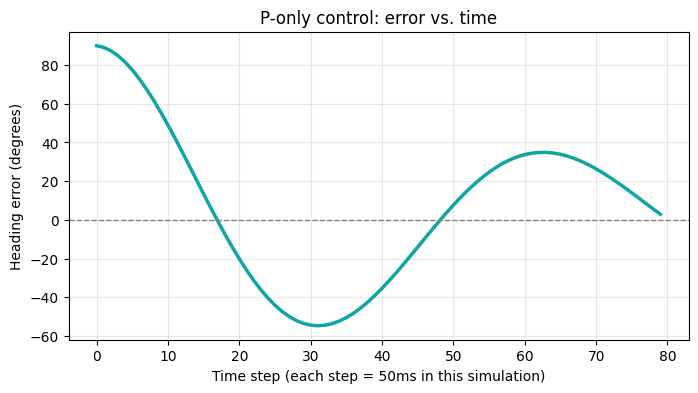

Final error after 80 steps: 2.87 degrees


In [ ]:

# P-only control: Ki = 0, Kd = 0
errors_p = simulate(Kp=4.0, Kd=0.0, Ki=0.0)

plt.figure(figsize=(8, 4))
plt.plot(errors_p, color="#0EA5A4", linewidth=2.5)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("P-only control: error vs. time")
plt.xlabel("Time step (each step = 50ms in this simulation)")
plt.ylabel("Heading error (degrees)")
plt.grid(alpha=0.3)
plt.show()

print(f"Final error after {len(errors_p)} steps: {errors_p[-1]:.2f} degrees")



**What you should see:** the error starts at 90°, swings past zero
(overshoot), comes back, overshoots again — an oscillation, and it likely
does **not** end exactly at 0° — there's a small leftover **steady-state
error** (P alone can't fully cancel the constant `disturbance=-2.5` in this
simulation, representing real-world drift).

### Try it — effect of Kp

Run the cell below with `Kp = 0.5`, `4.0`, and `12.0`.


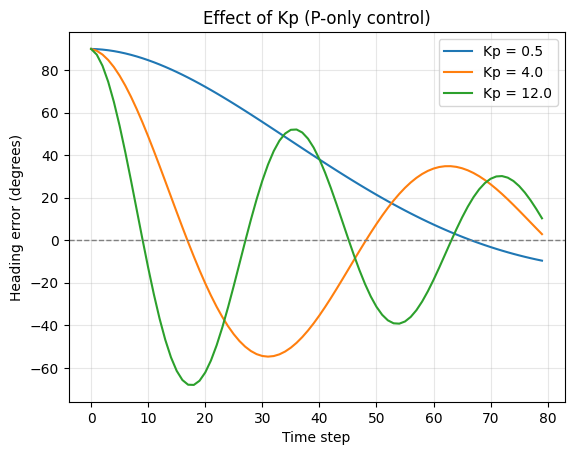

In [ ]:

for kp in [0.5, 4.0, 12.0]:
    errs = simulate(Kp=kp, Kd=0.0, Ki=0.0)
    plt.plot(errs, label=f"Kp = {kp}")

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Effect of Kp (P-only control)")
plt.xlabel("Time step")
plt.ylabel("Heading error (degrees)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



**What to notice:**
- `Kp = 0.5` (too low): slow approach, barely moves toward target in this
  window.
- `Kp = 4.0`: a reasonable decaying oscillation.
- `Kp = 12.0` (too high): bigger, possibly *growing* oscillations — the
  robot is overcorrecting faster than it can physically respond.

This matches `TURN_KP` / `STR_KP` — too low and turns are sluggish, too high
and the robot "buzzes" back and forth around the target.



## 3. D — Derivative: "Slow down if you're approaching fast"

### 3.1 The formula

```
correction += Kd * (error - last_error)
```

In `robot.py`:

```python
derivative = error - last_error
correction = (self.STR_KP * error) + (self.STR_KD * derivative)
```

### 3.2 The damper analogy

A mechanical damper (shock absorber) produces a force proportional to
**velocity**, opposing motion:

```
F = -b * x'(t)
```

A spring's force depends on *position*; a damper's force depends on *rate
of change of position*. D-control plays this role: `error - last_error`
(rate of change of error) ↔ `x'(t)`, `Kd` ↔ `b`.

### 3.3 The deeper math: the damped harmonic oscillator

Adding both a spring and a damper to our mass:

```
m * x''(t) = -k * x(t) - b * x'(t)
```

This is the **damped harmonic oscillator** — describes car suspensions,
building responses to earthquakes, and PD-controlled robots. The behavior
depends on the **damping ratio**:

```
ζ = b / (2 * sqrt(m*k))
```

- **ζ < 1 (underdamped)**: oscillates, but the oscillation *decays* over
  time. Usually what a well-tuned PD controller looks like — small
  overshoot, then settling.
- **ζ = 1 (critically damped)**: returns to rest in the *minimum possible
  time* without oscillating. The theoretical "ideal."
- **ζ > 1 (overdamped)**: returns to rest without oscillating, but more
  slowly than critical damping — "wading through honey."

For real robots, "too much Kd" usually shows up as **high-frequency
jitter** rather than textbook overdamping — `derivative = error -
last_error` is extremely sensitive to sensor noise. If the gyro jitters by
±0.1° between 10ms samples from noise alone, that's a derivative of ±10°/sec
— multiplied by a large `Kd`, the correction is mostly *responding to
noise*. This is the practical ceiling on `Kd`.

### 3.4 Why D doesn't fix steady-state error

D reacts to *changes* in error. If error is constant (steady state),
`de/dt = 0`, so D contributes nothing. **D can only affect the path to the
resting point, not the resting point itself.**


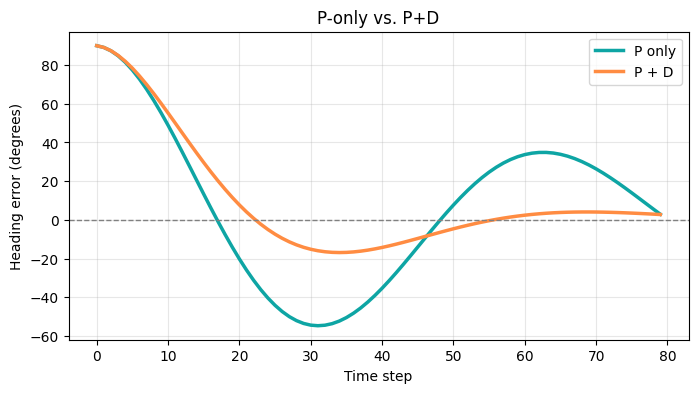

In [ ]:

errors_p  = simulate(Kp=4.0, Kd=0.0, Ki=0.0)
errors_pd = simulate(Kp=4.0, Kd=1.2, Ki=0.0)

plt.figure(figsize=(8, 4))
plt.plot(errors_p,  color="#0EA5A4", linewidth=2.5, label="P only")
plt.plot(errors_pd, color="#FF8C42", linewidth=2.5, label="P + D")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("P-only vs. P+D")
plt.xlabel("Time step")
plt.ylabel("Heading error (degrees)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



**What you should see:** P+D settles much faster, with a smaller overshoot.
Both curves still level off near a small nonzero value — D helps with
*oscillation*, but doesn't fix the leftover steady-state error.

### Try it — effect of Kd

What happens with `Kd` way too high, like 8.0?


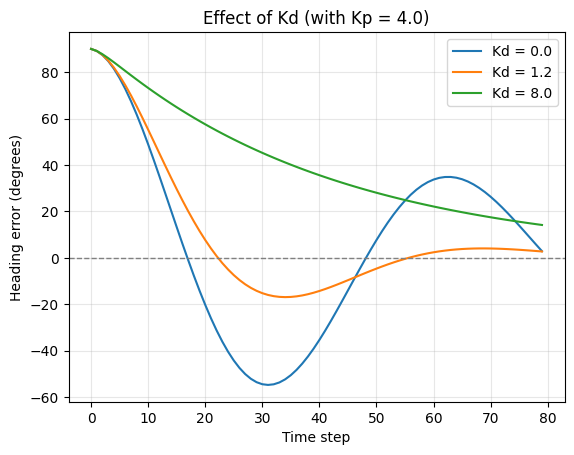

In [ ]:

for kd in [0.0, 1.2, 8.0]:
    errs = simulate(Kp=4.0, Kd=kd, Ki=0.0)
    plt.plot(errs, label=f"Kd = {kd}")

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Effect of Kd (with Kp = 4.0)")
plt.xlabel("Time step")
plt.ylabel("Heading error (degrees)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



**What to notice:** `Kd = 8.0` doesn't blow up like high `Kp` does — but on
a *real* robot, very high `Kd` reacts to tiny gyro noise and causes the
motors to twitch constantly. This simulation doesn't model sensor noise, so
it won't show that here — but it's the practical reason `Kd` can't just be
cranked up forever.



## 4. I — Integral: "Remember the past, fix what's left over"

### 4.1 The formula

```python
integral = max(min(integral + error, self.STR_I_CLAMP), -self.STR_I_CLAMP)
correction += self.STR_KI * integral
```

### 4.2 The integral as area under a curve

`∫₀ᵗ e(τ) dτ` is, geometrically, the **signed area** between the
error-vs-time curve and the time axis, from the start of the move to now.

### 4.3 Why `integral += error` is a Riemann sum

A **Riemann sum** approximates an integral by chopping the area under a
curve into thin rectangles and adding their areas. Each rectangle has width
`Δt` and height `e(tᵢ)`. Area of one rectangle = `e(tᵢ) * Δt`.

```
∫₀ᵗ e(τ) dτ  ≈  Σ e(tᵢ) * Δt   =   Δt * Σ e(tᵢ)
```

`Δt = 10ms` is constant every iteration, so it's a constant multiplier on
the whole sum — we absorb it into `Ki` and just track `Σ e(tᵢ)`. That's
exactly `integral = integral + error`: an unscaled Riemann sum, with `Δt`
and `Ki` combined into `STR_KI`/`TURN_KI`.

**Practical implication**: if the loop's `wait()` time changes, the
*effective* integral gain changes too, even if `STR_KI` stays the same —
because `Δt` is baked into the calibration of `Ki`.

### 4.4 The deeper math: why I eliminates steady-state error — a proof

Suppose the system reaches **steady state**: error settles to a constant
`e_ss ≠ 0` and stays there.

At steady state, `de/dt = 0`, so D contributes nothing. P contributes a
constant `Kp * e_ss`. For true equilibrium, this constant P output must
exactly balance whatever disturbance (friction, drift) causes the error.

Now consider I. If `e_ss ≠ 0`, every loop adds `e_ss` (nonzero constant) to
`integral`. **The integral cannot be constant if error is nonzero — it must
keep growing (or shrinking).** But we assumed steady state — total output
`u(t)` constant. If `integral` keeps changing while `Kp*e_ss` and `Kd*0` are
constant, then `Ki * integral` keeps changing — so `u(t)` is *not* actually
constant.

**Contradiction.** The only way for a true, unchanging steady state with a
nonzero integral term to exist is `e_ss = 0`. As long as `Ki ≠ 0` and the
integral isn't saturated, the *only* stable resting point is zero error.

### 4.5 Integral windup and the clamp

The proof above assumes the integral can grow as large as needed. In
reality: if the robot starts far from target, `integral` accumulates a large
value quickly (e.g. `error = 90°` for 20 loops before the robot starts
moving → `integral` already at 1800 before P/D have done much). When error
crosses zero and goes negative (overshoot), the *huge accumulated integral*
is still positive, and `Ki * integral` keeps pushing the original direction
— fighting the correction that should now happen. This is **integral
windup**, and it causes a large secondary overshoot.

`STR_I_CLAMP = 25` and `TURN_I_CLAMP = 10` cap `|integral|`. Maximum possible
I contribution = `Ki * I_CLAMP` — enough to nudge away small persistent
errors, but small enough to not dominate or cause severe windup. The clamp
is reapplied every loop, so it's a hard ceiling/floor on the running sum.


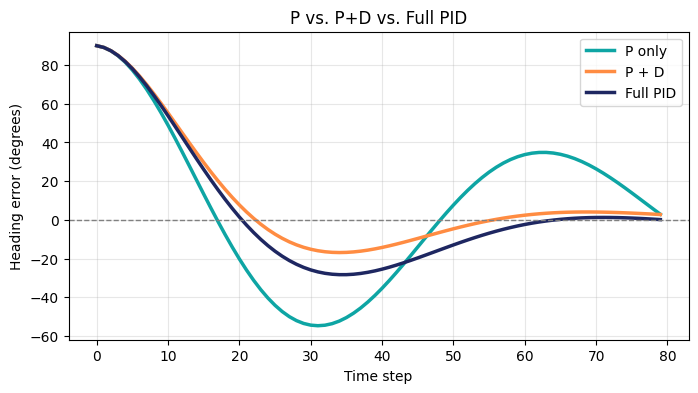

Final error - P only:   2.87
Final error - P+D:      2.75
Final error - Full PID: 0.12


In [ ]:

errors_p   = simulate(Kp=4.0, Kd=0.0, Ki=0.0)
errors_pd  = simulate(Kp=4.0, Kd=1.2, Ki=0.0)
errors_pid = simulate(Kp=4.0, Kd=1.2, Ki=0.8)

plt.figure(figsize=(8, 4))
plt.plot(errors_p,   color="#0EA5A4", linewidth=2.5, label="P only")
plt.plot(errors_pd,  color="#FF8C42", linewidth=2.5, label="P + D")
plt.plot(errors_pid, color="#1E2761", linewidth=2.5, label="Full PID")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("P vs. P+D vs. Full PID")
plt.xlabel("Time step")
plt.ylabel("Heading error (degrees)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Final error - P only:   {errors_p[-1]:.2f}")
print(f"Final error - P+D:      {errors_pd[-1]:.2f}")
print(f"Final error - Full PID: {errors_pid[-1]:.2f}")



**The story in one chart:**
- **P only**: gets close, oscillates, leaves a leftover error.
- **P+D**: settles much faster with less overshoot, but still has a small
  leftover error.
- **Full PID**: similar early behavior, but the integral term slowly grinds
  the leftover error toward zero.

> "P reacts to **now**, D predicts the **future**, I remembers the **past**."

### Try it — integral windup


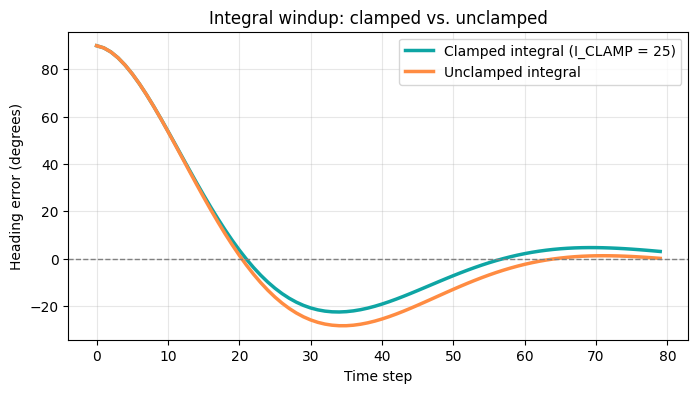

In [ ]:

errors_clamped   = simulate(Kp=4.0, Kd=1.2, Ki=0.8, i_clamp=25)   # like STR_I_CLAMP
errors_unclamped = simulate(Kp=4.0, Kd=1.2, Ki=0.8, i_clamp=10000) # essentially no clamp

plt.figure(figsize=(8, 4))
plt.plot(errors_clamped,   color="#0EA5A4", linewidth=2.5, label="Clamped integral (I_CLAMP = 25)")
plt.plot(errors_unclamped, color="#FF8C42", linewidth=2.5, label="Unclamped integral")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Integral windup: clamped vs. unclamped")
plt.xlabel("Time step")
plt.ylabel("Heading error (degrees)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



**What to notice:** the unclamped version overshoots much further on its way
back through zero — the accumulated integral from the big initial error is
still "pushing" even after the robot has turned past the target. The clamp
caps the *maximum possible contribution* of I (`Ki * I_CLAMP`), enough to nudge
away small persistent errors without letting it dominate.

### 4.6 P, I, D as "Now, Past, Future" — and why the ordering makes sense

- **P** responds to **where the error is right now**. (Position-like.)
- **D** responds to **where the error is heading** — its instantaneous rate
  of change. (Velocity-like — a short-term prediction.)
- **I** responds to **where the error has been** — its accumulated history.
  (An integral of position over time — dimensionally one step "behind"
  position, the way position is one step "behind" velocity.)

I is the time-integral of P's input; D is the time-derivative of P's input.
Three terms, three different "time relationships" to the same error signal.



## 5. From Continuous Math to a 10ms While-Loop

### 5.1 The general principle

| Continuous Math | Discrete Approximation | Approximation type | In `robot.py` |
|---|---|---|---|
| `e(t)` | `error` | Direct sample | `error = self.get_shortest_error(target)` |
| `de(t)/dt` | `(error - last_error) / dt` | Finite difference (backward) | `derivative = error - last_error` (dt folded into Kd) |
| `∫e(t)dt` | `Σ(error * dt)` | Riemann sum (left rectangle rule) | `integral = integral + error` (dt folded into Ki) |

Both `Δt`s are constant (10ms, from `wait(10)`), so they're absorbed into
`STR_KD`/`TURN_KD` and `STR_KI`/`TURN_KI`. This is valid *as long as loop
timing stays consistent* — if some code path adds extra delay before
`wait(10)`, that iteration's effective `Δt` is larger, and the gains are
slightly less calibrated for that step. Usually a second-order effect, but
worth knowing it exists.

### 5.2 Why 10ms?

- **Smaller `Δt`** (faster loop): closer approximations to continuous math →
  smoother control, but more CPU per second. Below some threshold, sensor
  noise and motor response time dominate anyway.
- **Larger `Δt`** (slower loop): cheaper, but worse approximations —
  especially the derivative, since it's a secant line over a longer
  interval, and the controller reacts to a "stale" error for longer.

10ms (100Hz) is well within the hub's capability, fast relative to the
robot's physical response time, and slow enough that per-loop computation is
trivial.

### 5.3 The deeper math: discrete-time stability (why high Kp can cause *growing* oscillation)

In the continuous analogy (Section 2.3), P-only control on an inertial
system oscillates at *constant* amplitude — it doesn't grow. But real
digital controllers sample and act with a **one-step delay**: the
correction computed this iteration is based on an error measured *before*
this iteration's motor command takes effect, and the motor command's effect
isn't felt until the *next* iteration's sample.

This delay has no continuous analog, and it means that for sufficiently high
`Kp` (relative to `Δt` and the system's inertia), the oscillation can
actually **grow** over time — the controller is always "correcting for where
the error was 10ms ago," and if it overcorrects faster than the system can
respond, each cycle's overshoot is larger than the last. This is the formal
reason "Kp too high" can look like a *diverging* oscillation — and why `Kd`
(which directly counteracts the rate-of-change driving the overshoot) is so
effective at taming it.


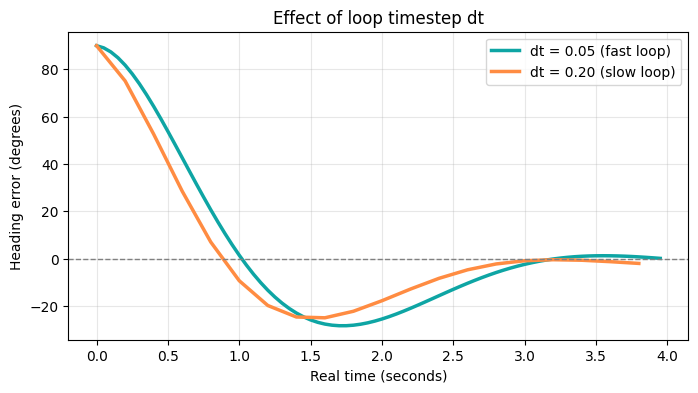

In [ ]:

errors_fast = simulate(Kp=4.0, Kd=1.2, Ki=0.8, dt=0.05, steps=80)
errors_slow = simulate(Kp=4.0, Kd=1.2, Ki=0.8, dt=0.20, steps=20)  # fewer steps, same total time

# rescale x-axis to "real time" so both lines compare fairly
t_fast = np.arange(len(errors_fast)) * 0.05
t_slow = np.arange(len(errors_slow)) * 0.20

plt.figure(figsize=(8, 4))
plt.plot(t_fast, errors_fast, color="#0EA5A4", linewidth=2.5, label="dt = 0.05 (fast loop)")
plt.plot(t_slow, errors_slow, color="#FF8C42", linewidth=2.5, label="dt = 0.20 (slow loop)")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Effect of loop timestep dt")
plt.xlabel("Real time (seconds)")
plt.ylabel("Heading error (degrees)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



**What to notice:** the slower loop (`dt = 0.20`) is "chunkier" — it reacts
to a stale error for longer each step, so its derivative and integral
approximations are coarser. On real hardware this can show up as a less
smooth, less precise response.



## 6. Tuning Theory and Recipe

### 6.1 Ziegler-Nichols, and why we use a simplified version

The classic **Ziegler-Nichols** method finds `Ku` (the "ultimate gain" — the
`Kp` at which the system oscillates with *constant* amplitude under P-only
control) and `Tu` (the period of that oscillation), then prescribes
`Kp`/`Ki`/`Kd` as specific fractions/multiples of `Ku` and `Tu`.

For FLL robots, finding a precise `Ku`/`Tu` is impractical — "constant
amplitude oscillation" is a knife-edge condition, hard to hit exactly with
limited test space, and risky (the robot moving unpredictably). The
simplified recipe below captures the *spirit* — using the onset of
oscillation as a calibration reference — without requiring precise period
measurements. It trades some theoretical optimality for practicality and
safety.

### 6.2 Why this order: Kp → Kd → Ki

1. **Kp first** — it's the dominant term, determines the basic character of
   the response. Tuning Kd/Ki against a poorly-chosen Kp means re-tuning them
   again once Kp changes.
2. **Kd second** — its job is to clean up the *transient* that Kp alone
   creates (Section 2.3/2.4 oscillation). Tuned *in response to* whatever Kp
   produced.
3. **Ki last** — its effects only become visible *after* the system has
   mostly settled (Section 4.4 — acts on steady-state behavior). If Kp/Kd
   aren't reasonable yet, the system may never settle long enough for Ki's
   effect to be observable.

### 6.3 The recipe

1. **Set `Ki = 0` and `Kd = 0`.** Slowly raise `Kp` until the robot just
   starts to oscillate (overshoot, come back, overshoot less, settle). Note
   this value as `Kp_osc`.
2. **Back `Kp` off to ~50-60% of `Kp_osc`.** Should approach quickly with a
   small, controlled overshoot.
3. **Raise `Kd`** until that overshoot mostly disappears and the robot
   settles in fewer loops. Too much Kd → jittery motor sounds.
4. **Raise `Ki`** from 0 in small steps (e.g. 0.01-0.05) until the small
   leftover steady-state error disappears, without a slow back-and-forth
   drift.
5. **Validate with BlackBox** (Section 9): run the same move 5-10 times,
   check consistency score and average error in `print_diagnostic_report()`.


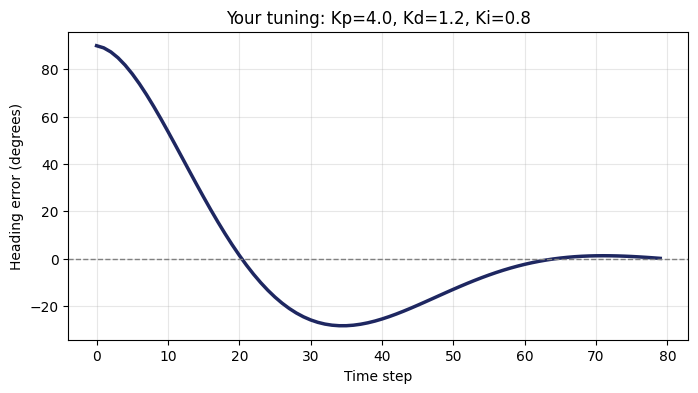

Overshoot: 28.35 degrees
Final error: 0.12 degrees
Settled under 1 deg by step: 75


In [ ]:

# ---- YOUR TURN: change these three numbers ----
my_Kp = 4.0
my_Kd = 1.2
my_Ki = 0.8
# -------------------------------------------------

errs = simulate(Kp=my_Kp, Kd=my_Kd, Ki=my_Ki)

plt.figure(figsize=(8, 4))
plt.plot(errs, color="#1E2761", linewidth=2.5)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title(f"Your tuning: Kp={my_Kp}, Kd={my_Kd}, Ki={my_Ki}")
plt.xlabel("Time step")
plt.ylabel("Heading error (degrees)")
plt.grid(alpha=0.3)
plt.show()

overshoot = -min(errs)  # how far past zero (negative direction) it went
final_error = errs[-1]
settled_at = next((i for i, e in enumerate(errs) if abs(e) < 1.0 and all(abs(x) < 1.0 for x in errs[i:])), None)

print(f"Overshoot: {overshoot:.2f} degrees")
print(f"Final error: {final_error:.2f} degrees")
print(f"Settled under 1 deg by step: {settled_at}")



## 7. Why Separate Gain Sets? (`STR_*` vs `TURN_*` vs pivot's local gains)

The straight-line controller and the turning controllers are *different
physical systems* from a control-theory standpoint:

- **Straight driving**: both wheels move in the same direction at similar
  speeds; the "error" being corrected is a small heading deviation while most
  motor power goes into forward motion. The correction is a small
  *differential* adjustment on top of a large common-mode drive signal.
- **Tank turning**: both wheels move in *opposite* directions; the entire
  motor output *is* the correction — no separate "drive" signal to perturb.
- **Pivot turning**: only one wheel moves; the stationary wheel's contact
  point acts as a pivot with its own friction characteristics, different from
  either of the above.

Because the relationship between "motor command" and "resulting angular
response" (effective inertia and friction, in the spring/damper analogy) is
different for each, each needs its own `Kp`/`Ki`/`Kd` — one gain set for all
three would mean at best one is well-tuned and the others are compromises.
This is why `turn_pivot()` has its own local `kp, ki, kd = 4.5, 0.12, 6.0`
distinct from the class-level `TURN_KP/KI/KD` used by `turn_tank()`.



## 8. Real Hardware: Dead Zones and Floors as *Non-PID* Corrections

It's worth being explicit: `TURN_FLOOR`, `PIVOT_FLOOR`, and the dead-zone
threshold (currently 0.8°) are **not** part of the PID formula — they're
*post-processing* on the PID output, accounting for things the linear PID
model doesn't capture.

### 8.1 Motors have friction

A very small commanded power (say, 3 out of 100) often isn't enough to
overcome friction in the gears — the motor just sits there buzzing, doing
nothing useful. PID math would happily compute that tiny number forever.

**The fix — floors**: `if abs(pwr) < FLOOR: pwr = FLOOR if pwr > 0 else
-FLOOR`. "The PID formula computed a small nonzero correction, and we *do*
want to correct — but a power this small won't actually move the motor due
to friction, so round it up to the smallest power that *will* move it." This
is a deliberate departure from the math, justified by static friction
("stiction") not being part of the idealized spring/damper model.

- **`TURN_FLOOR = 18`**
- **`PIVOT_FLOOR = 30`** — pivot turns need more power to overcome friction
  on the stopped wheel's contact point.

### 8.2 Sensors have noise

The gyro reading jitters slightly even when the robot is perfectly still. If
PID corrects every tiny jitter, the motors twitch constantly.

**The fix — dead zone**: `if abs(error) < 0.8: pwr = 0`. "The PID formula
might compute some small nonzero correction here, but errors this small
aren't worth correcting — likely sensor noise, and correcting them would
just cause jitter." A deliberate departure from the math, justified by
Section 3.3's noise-sensitivity discussion.

### 8.3 Real example from this season

Pivot turns were jittering near the target. The fix wasn't a different PID
gain — it was widening the dead zone from 0.5° to 0.8° and setting
`PIVOT_FLOOR = 30`. Small parameter changes *outside* the PID formula itself
had a big effect on real behavior.

This is **why empirical validation matters** — no amount of recomputing the
PID formula on paper would reveal the right dead zone width or floor value.
Both were found by running the robot and watching what actually happened.



## 9. Validate With BlackBox

### 9.1 Why this matters, from a control-theory perspective

PID tuning is fundamentally an **empirical optimization problem**: searching
a 3-dimensional space (`Kp`, `Ki`, `Kd` — or more, with separate gain sets)
for values that minimize "error" across real runs, subject to real-world
noise (floor surface variance, battery voltage drop, mechanical differences
run-to-run). A single test run is a *noisy sample* from this space — a good
run with bad gains, or a bad run with good gains, are both common.
`season_analysis.py`'s consistency score and error trend slope exist
precisely to separate the *signal* (does this gain change actually help, on
average, accounting for variance) from the *noise* (this run happened to go
well/badly).

### 9.2 A/B testing as informal hypothesis testing

The `USE_KALMAN` flag pattern — run N trials with the flag off, N with it on,
compare consistency scores — is an informal A/B test / paired comparison.
Even just "did average error AND its spread both improve, by more than
run-to-run variance would suggest by chance" is enough to make a defensible
tuning decision — dramatically better than changing a gain once and
declaring victory after a single good run.

### 9.3 The workflow

1. **Make ONE change.** Adjust a single gain (e.g. `STR_KD`) or flip a flag
   (e.g. `USE_KALMAN`). Changing multiple things at once makes it impossible
   to know what helped.
2. **Run it 5-10 times.** Same mission, same starting position.
   `print_diagnostic_report()` shows per-move error and bias for each run.
3. **Compare in `season_analysis.py`.** Consistency score, average error,
   and bias trend — before vs. after, side by side.
4. **Keep it or revert.** If the new value didn't clearly improve
   consistency score and average error, go back — and try a different
   change.



## 10. Cheat Sheet

```
correction = Kp*error + Ki*integral + Kd*(error - last_error)
```

| Term | Represents | Analogy | Math | Effect |
|---|---|---|---|---|
| **P** | Now | Spring (`F=-kx`) | Simple harmonic oscillator | Pushes proportional to current error. Alone, causes oscillation. |
| **I** | Past | Accumulator | Riemann sum (`Σe·dt`) | Kills steady-state error (proof in 4.4). Clamp it! |
| **D** | Future | Damper (`F=-bv`) | Damped harmonic oscillator (`ζ`) | Reduces overshoot. Too much → jittery. |

**Discretized in code:** error each 10ms loop → `derivative = error -
last_error` → `integral += error` (clamped) → tune with the Kp→Kd→Ki recipe
→ validate with BlackBox.

---

## 11. Glossary

- **Error `e(t)`**: target minus actual, as a function of time.
- **Gain (`Kp`, `Ki`, `Kd`)**: a constant multiplier on each term; the
  "tuning knobs."
- **Steady state**: the system has stopped changing — error and output both
  constant (possibly nonzero).
- **Steady-state error**: the nonzero error the system settles to, if any.
- **Transient**: the system's behavior *before* steady state — approach,
  overshoot, settling.
- **Overshoot**: how far past the target the system goes before correcting
  back.
- **Damping ratio (`ζ`)**: dimensionless number describing how oscillatory a
  second-order system is (underdamped/critical/overdamped).
- **Integral windup**: excessive accumulation of the integral term during a
  period of large/persistent error, causing overcorrection once the error
  changes sign.
- **Riemann sum**: an approximation of an integral as a sum of rectangle
  areas.
- **Finite difference**: an approximation of a derivative as
  `(f(t) - f(t-Δt)) / Δt`.
- **Dead zone**: a region around zero error where the controller
  deliberately applies no correction.
- **Floor**: a minimum output magnitude applied whenever the controller
  outputs a nonzero-but-too-small value, to overcome static friction.

---

## 12. How This Maps to the Roadmap

The Kalman filter item (`USE_KALMAN` / `KALMAN_K`, A/B tested via BlackBox)
is the most direct continuation of the ideas in this notebook: a
complementary filter is itself a tiny "I-like" weighted blend
(`estimate = K * gyro + (1-K) * other_sensor`), and validating `KALMAN_K`
follows exactly the methodology in Section 9 — same pattern as validating
`STR_KD` or `TURN_KI`, just applied to a measurement filter instead of a
controller.

The line follower's FSM and PID color-sensor loop will also reuse this same
P/I/D/dead-zone/floor vocabulary, just with "line position error" in place
of "heading error" — once the concepts here are solid, the line follower is
mostly a matter of substituting in a new sensor and a new error definition.

---


## 13. Sensor Fusion: The Kalman Filter (and the Complementary Filter We're Using)

### 13.1 The problem: no single sensor tells the whole truth

The gyro's `heading()` reading isn't measured directly — internally it's
built by **integrating** angular velocity over time:

```
heading(t) = heading(0) + ∫₀ᵗ ω(τ) dτ
```

This is the *same* Riemann-sum idea from Section 4.3 — and it has the same
weakness as any integral built from imperfect data: if the rate sensor has
even a tiny constant bias (say, it reads 0.05°/sec when the robot is
perfectly still), that bias gets *integrated too* — and integrating a
constant gives something that grows linearly with time. This is **gyro
drift**: small, slow, but it never goes away on its own, and it compounds
over a whole match.

A second sensor (e.g. an accelerometer-derived tilt estimate, or a
secondary heading estimate from wheel odometry) might be **noisy** —
jumps around a lot from one reading to the next — but has **no drift**: its
errors don't accumulate over time, they just average out.

So we have two imperfect sources:
- **Gyro**: smooth and responsive *short-term*, but drifts *long-term*.
- **Other sensor**: noisy *short-term*, but has no long-term drift.

Neither alone is great. But notice they fail in *opposite* ways — which is
exactly the setup where blending them can beat either one alone.

### 13.2 The complementary filter: a weighted average

The simplest possible blend:

```
estimate = K * gyro_reading + (1 - K) * other_sensor_reading
```

`K` is a single number between 0 and 1 — one knob. If `K` is close to 1, we
mostly trust the gyro (smooth, but will drift slowly toward the other
sensor's value). If `K` is close to 0, we mostly trust the other sensor
(noisy, but self-correcting).

This is called a **complementary filter** because the two sensors'
*error characteristics* are complementary: the gyro is good where the other
sensor is bad (short-term smoothness) and vice versa (long-term drift). The
blend gets the best of both.

### 13.3 The deeper math: why a weighted average is *optimal* (not just "reasonable")

Here's a question worth sitting with: *why a weighted average, and why
these particular weights?* This isn't arbitrary — it falls out of a short
optimization.

Suppose we have two independent measurements of the same true quantity,
`m₁` and `m₂`, with **variances** `σ₁²` and `σ₂²` (variance = how spread out
/ noisy a measurement tends to be — bigger variance means less trustworthy).
Consider a general weighted combination:

```
estimate = w * m₁ + (1 - w) * m₂
```

Because `m₁` and `m₂` are independent, variances of independent quantities
*add* when you scale and sum them. The variance of our estimate is:

```
Var(estimate) = w² * σ₁²  +  (1 - w)² * σ₂²
```

We want to choose `w` to **minimize** this — i.e., find the blend that
produces the *least noisy* possible estimate. Take the derivative with
respect to `w` and set it to zero:

```
d/dw [ w²σ₁² + (1-w)²σ₂² ]  =  2wσ₁² - 2(1-w)σ₂²  =  0
```

Solving:

```
w·σ₁² = (1-w)·σ₂²
w·σ₁² = σ₂² - w·σ₂²
w·(σ₁² + σ₂²) = σ₂²
w = σ₂² / (σ₁² + σ₂²)
```

And by symmetry, `(1 - w) = σ₁² / (σ₁² + σ₂²)`.

**Read that result carefully**: the weight on `m₁` is proportional to
`σ₂²` — the *other* sensor's variance. **The noisier a sensor is, the LESS
weight it gets, and that weight is determined by how noisy the OTHER
sensor is, in exactly the right proportion to minimize total noise.**
This is the **optimal** linear blend — provably the lowest-variance
estimate possible from these two measurements. `K` in our complementary
filter is exactly this kind of weight: `K ≈ σ_other² / (σ_gyro² +
σ_other²)`, fixed at a value we choose ahead of time based on roughly how
noisy each sensor is.

### 13.4 The full Kalman filter: the same idea, but the weight updates itself

Everything in 13.3 assumed `σ₁²` and `σ₂²` are fixed numbers we know ahead
of time. A **Kalman filter** is what you get when you let the "variance of
my current estimate" change over time and **recompute the optimal weight
every single loop** based on the *current* uncertainty — rather than using
one fixed `K` forever.

Concretely, a Kalman filter tracks two things every loop:
- `x̂` — the current best estimate (like our `estimate` above)
- `P` — the current *uncertainty* (variance) of that estimate

Each loop has two steps:

**Predict** (before the new measurement arrives): if we haven't measured
anything new, our uncertainty can only get *worse* — `P` increases by some
amount `Q` (how much we expect things to drift between measurements).

**Update** (a new measurement arrives, with its own known noise variance
`R`): compute the **Kalman gain**:

```
gain = P / (P + R)
```

— this is *exactly* the `w = σ₂²/(σ₁²+σ₂²)` formula from 13.3, with `P`
playing the role of "my current uncertainty" and `R` the role of "the new
measurement's uncertainty." Then:

```
x̂ = x̂ + gain * (measurement - x̂)     # blend toward the new measurement
P = (1 - gain) * P                     # uncertainty shrinks after measuring
```

**The key difference from our complementary filter**: `gain` is *not* a
constant we picked — it's *recomputed every loop* from `P` and `R`. When
the estimate is very uncertain (`P` large), `gain` is close to 1 — trust the
new measurement heavily. When the estimate is already very confident (`P`
small), `gain` is close to 0 — barely move, the new measurement probably
isn't telling us much we don't know. **A Kalman filter is a complementary
filter where `K` continuously re-tunes itself based on how confident the
filter currently is** — the same optimal-weighted-average idea from 13.3,
applied fresh every single loop.

### 13.5 Why we're implementing the complementary filter, not the full Kalman filter

Given 13.3 and 13.4, the practical tradeoff is:

- **Complementary filter**: one constant, `KALMAN_K`, chosen ahead of time
  and tuned empirically (Section 9's A/B testing). One line of code per
  loop. The *math* behind picking a good `K` is the optimization in 13.3 —
  real, provable, and exactly the same idea a full Kalman filter uses.
- **Full Kalman filter**: tracks `P` and recomputes `gain` every loop based
  on `Q` and `R` — which themselves need to be estimated/tuned, and the
  filter is doing real work (a division, several multiplications) every
  10ms loop.

For our gyro, the noise characteristics don't change dramatically loop to
loop — there's no scenario where the gyro suddenly becomes much more or
less trustworthy mid-match. That means the *value* of letting `gain`
re-tune itself every loop (the full Kalman filter's whole advantage over
13.3's fixed-weight version) is small for this specific sensor. We're
implementing the math of 13.3 — a fixed, empirically-tuned optimal blend —
under the name `USE_KALMAN` / `KALMAN_K`, because it captures the *real
idea* (combine two complementary error sources via a principled weighted
average) without the extra per-loop computation and extra tuning parameters
(`Q`, `R`) that a full Kalman filter would add.

**This is not "the easy version instead of the real version."** The
complementary filter *is* a Kalman filter — specifically, a Kalman filter
for the special case where the optimal gain happens to be constant. We're
choosing the right tool for a sensor whose noise characteristics are stable.

### 13.6 Connecting back to the I term (Section 4)

There's a nice symmetry worth pointing out: the I term in Section 4 also
*combines current information with accumulated history* — `integral +=
error` blends "what's happening now" with "everything that's happened so
far." The complementary filter does something structurally similar:
`estimate = K*gyro + (1-K)*other` blends "what the fast-but-drifting sensor
says now" with "what the slow-but-stable sensor says." Both are weighted
combinations of a "now" signal and a "remembered/other" signal — just
applied to *measurement* (Kalman/complementary filter) instead of *control*
(PID's I term).

### 13.7 Validating `KALMAN_K` (ties to Section 9)

Exactly the Section 9 workflow, applied to a measurement filter instead of a
controller gain:

1. Pick a few candidate `KALMAN_K` values (e.g. 0.90, 0.95, 0.98, 0.995).
2. For each value, run the same mission 5-10 times with `USE_KALMAN = True`.
3. Compare consistency scores and average error in `season_analysis.py`
   against the `USE_KALMAN = False` baseline.
4. Pick the `KALMAN_K` that best improves consistency — or confirm that, for
   this robot, the difference isn't large enough to matter (also a valid,
   useful result!).


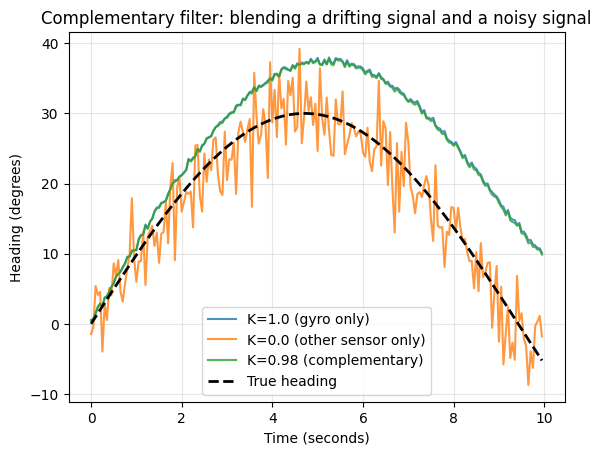

In [ ]:
# A small demo: blending a "drifting but smooth" signal with a
# "noisy but unbiased" signal using a complementary filter.

np.random.seed(0)
n = 200
t = np.arange(n) * 0.05  # 50ms steps, 10 seconds total

true_heading = 30 * np.sin(t / 3)  # the real heading, slowly changing

# Gyro-style signal: smooth, but with a small constant drift added in
gyro_drift_rate = 1.5  # degrees per second of drift
gyro_signal = true_heading + gyro_drift_rate * t + np.random.normal(0, 0.3, n)

# "Other sensor": noisy, but centered on the true value (no drift)
other_signal = true_heading + np.random.normal(0, 4.0, n)

def complementary_filter(gyro, other, K):
    return K * gyro + (1 - K) * other

for K in [1.0, 0.0, 0.98]:
    blended = complementary_filter(gyro_signal, other_signal, K)
    label = {1.0: "K=1.0 (gyro only)", 0.0: "K=0.0 (other sensor only)", 0.98: "K=0.98 (complementary)"}[K]
    plt.plot(t, blended, label=label, alpha=0.8)

plt.plot(t, true_heading, color="black", linestyle="--", linewidth=2, label="True heading")
plt.title("Complementary filter: blending a drifting signal and a noisy signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Heading (degrees)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


**What you should see:**
- **K=1.0 (gyro only)**: starts accurate, but visibly drifts away from the
  true heading (black dashed line) as time goes on — the drift accumulates.
- **K=0.0 (other sensor only)**: stays centered on the true heading on
  average, but is visibly noisy/jittery the whole time.
- **K=0.98 (complementary)**: tracks the true heading closely *and* stays
  smooth — taking advantage of the gyro's short-term smoothness while the
  small `(1-K)` contribution from the other sensor continually nudges away
  the drift before it can build up.

### Try it

Change `K` to a few different values (try `0.999`, `0.9`, `0.5`) and
re-run. At what point does drift start creeping back in? At what point
does it get noisy again? Where's the sweet spot for *this* simulated data —
and would that same `K` necessarily be right for the real robot's actual
sensors? (It wouldn't — this is exactly why `KALMAN_K` gets tuned
empirically with BlackBox, not calculated from a simulation like this one.)


## 14. Reliability Math: Why "Consistency Score" Is a Real Number, Not a Vibe

### 14.1 Average error isn't the whole story

Suppose two versions of `turn_tank()` are tested 10 times each, and both
average **2.0° of error**. Are they equally good?

Not necessarily — it depends on the *spread*:

- **Version A**: errors cluster tightly around 2.0° (say, 1.8° to 2.2°
  every time). Predictable.
- **Version B**: errors average 2.0° but bounce between 0.1° and 6.0°.
  Sometimes great, sometimes terrible.

Same average. Very different robots. In a competition where one bad turn
can cost an entire mission, **Version A is almost always the better
choice** — even though "average error" alone can't distinguish them.

### 14.2 Mean and standard deviation

The **mean** (μ) is the familiar average: sum of all values divided by how
many there are.

The **standard deviation** (σ) measures *spread* — roughly, "how far do
individual runs typically deviate from the mean?" It's computed as:

```
σ = sqrt( (1/n) * Σ(xᵢ - μ)²  )
```

In words: for each run, find how far it is from the mean, square that
(so negative and positive deviations don't cancel out, and big deviations
count more than small ones), average those squared deviations, then take
the square root (to get back to the original units — degrees, not
degrees²).

A small σ means runs are consistent (close to the mean every time). A large
σ means runs are erratic (sometimes close, sometimes far).

### 14.3 Coefficient of variation: one number for "consistency"

Comparing σ values directly can be misleading if the means are different
— 1° of spread around a 2° average is a lot more variation (relatively)
than 1° of spread around a 20° average. The **coefficient of variation**
normalizes for this:

```
CV = σ / μ
```

A lower CV means *more consistent relative to its own average* — this is a
reasonable single-number "consistency score." (In practice, `μ` should be
the average of `|error|`, since signed errors near zero could make `μ`
tiny or even zero and blow up the ratio — `season_analysis.py` should use
absolute error for this calculation.)

### 14.4 Why this matters for competition strategy: expected value across rounds

FLL gives you **multiple match attempts**, and your *best* score across
attempts usually counts. This changes the math of what "better" means.

Consider two tunings:

- **Tuning A**: every run scores around 70 points, ±5.
- **Tuning B**: every run scores around 75 points on average, but ranges
  from 40 to 95 — high variance.

Tuning B has the higher *mean*. But across, say, 3 attempts, Tuning A
reliably nets you something close to 70 every time. Tuning B *might* hit 95
once — but might also hit 40 on a bad run, and if your *best of 3* happens
to all be bad rolls, you could end up below Tuning A's worst case. **High
variance is a gamble; low variance is closer to a guarantee.** Whether the
gamble is worth it depends on how far behind you are and how many attempts
you have left — but it's a genuinely different *kind* of decision than just
"which has the higher average," and consistency score is the number that
lets you reason about it explicitly instead of by feel.


Tuning A (tight): mean=1.97°  std=0.36°  CV (consistency score)=0.18
Tuning B (wide): mean=2.04°  std=1.40°  CV (consistency score)=0.69


/tmp/ipykernel_577/1632717444.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([tuning_A, tuning_B], labels=["Tuning A", "Tuning B"])


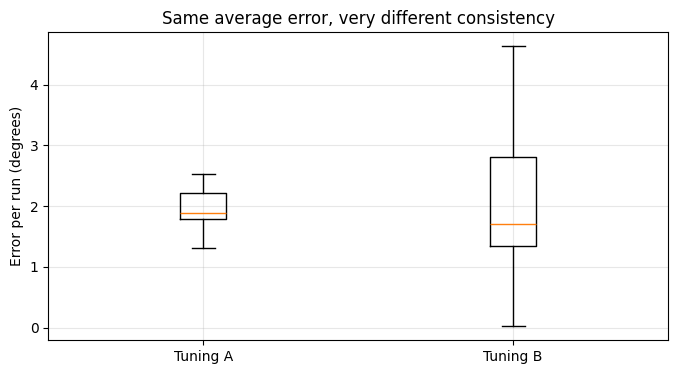

In [ ]:
# Simulate two "tunings" with the same mean error but different spread,
# and compute mean, standard deviation, and coefficient of variation for each.

np.random.seed(1)

tuning_A = np.abs(np.random.normal(loc=2.0, scale=0.3, size=10))  # tight spread
tuning_B = np.abs(np.random.normal(loc=2.0, scale=1.8, size=10))  # wide spread

def stats(name, errors):
    mu = np.mean(errors)
    sigma = np.std(errors)
    cv = sigma / mu
    print(f"{name}: mean={mu:.2f}°  std={sigma:.2f}°  CV (consistency score)={cv:.2f}")
    return mu, sigma, cv

stats("Tuning A (tight)", tuning_A)
stats("Tuning B (wide)", tuning_B)

plt.figure(figsize=(8, 4))
plt.boxplot([tuning_A, tuning_B], labels=["Tuning A", "Tuning B"])
plt.ylabel("Error per run (degrees)")
plt.title("Same average error, very different consistency")
plt.grid(alpha=0.3)
plt.show()


**What you should see:** both tunings have similar means (close to 2.0°),
but Tuning A's box-and-whisker plot is short and tight, while Tuning B's is
tall and spread out — and Tuning B likely has a much higher CV. If
`season_analysis.py` only reported the mean, these would look almost
identical. The CV is what reveals the real difference.

### Try it

Re-run the cell above a few times (the random seed makes it
reproducible, but try removing `np.random.seed(1)` and running multiple
times). Does Tuning A's CV stay consistently lower than Tuning B's? With
only 10 samples, how much does the CV itself bounce around — and what does
that tell you about *how many runs* you'd want before trusting a
consistency score comparison?


### 14.5 Computing σ by hand — a worked example

Before letting numpy do it, it's worth computing a standard deviation by
hand once. Suppose `turn_tank()` is run 5 times, with final errors (in
degrees):

```
2.0, 1.5, 2.5, 1.0, 3.0
```

**Step 1 — Mean:**
```
μ = (2.0 + 1.5 + 2.5 + 1.0 + 3.0) / 5 = 10.0 / 5 = 2.0
```

**Step 2 — Deviations from the mean** (`xᵢ - μ`):
```
2.0 - 2.0 =  0.0
1.5 - 2.0 = -0.5
2.5 - 2.0 =  0.5
1.0 - 2.0 = -1.0
3.0 - 2.0 =  1.0
```

**Step 3 — Square each deviation** (this is *why* σ uses squares — it makes
every term positive, so the +0.5 and -0.5 don't cancel out, and it
penalizes the ±1.0 deviations 4x more than the ±0.5 ones, since `1.0² = 1.0`
but `0.5² = 0.25` — *bigger* misses count *disproportionately* more):
```
0.0² = 0.00
-0.5² = 0.25
0.5²  = 0.25
-1.0² = 1.00
1.0²  = 1.00
```

**Step 4 — Average the squared deviations** (this quantity is called the
**variance**, often written `σ²`):
```
σ² = (0.00 + 0.25 + 0.25 + 1.00 + 1.00) / 5 = 2.5 / 5 = 0.5
```

**Step 5 — Square root to get back to degrees** (variance is in
degrees², which isn't a unit anyone can picture — taking the square root
converts back to degrees):
```
σ = sqrt(0.5) ≈ 0.71
```

**Step 6 — Coefficient of variation:**
```
CV = σ / μ = 0.71 / 2.0 ≈ 0.35
```

So this set of 5 runs has a mean error of 2.0°, a standard deviation of
about 0.71°, and a CV of about 0.35.


In [ ]:
# Verify the hand-computed example with numpy
errors_example = np.array([2.0, 1.5, 2.5, 1.0, 3.0])

mu = np.mean(errors_example)
variance = np.mean((errors_example - mu) ** 2)
sigma = np.sqrt(variance)
cv = sigma / mu

print(f"Mean (mu):      {mu}")
print(f"Variance (sigma^2): {variance}")
print(f"Std dev (sigma):    {sigma:.4f}")
print(f"CV (sigma/mu):      {cv:.4f}")


Mean (mu):      2.0
Variance (sigma^2): 0.5
Std dev (sigma):    0.7071
CV (sigma/mu):      0.3536


### 14.6 Two different reliability numbers in `print_diagnostic_report()`

`print_diagnostic_report()` already prints two quantities that sound similar
but answer *different* questions — worth being precise about the
distinction:

```python
total_err = sum(abs(e) for _, _, e in self.report_card)
avg_err   = total_err / len(self.report_card)
bias      = sum(e for _, _, e in self.report_card)
```

- **`avg_err`** (average of `|error|`, *unsigned*) answers: **"on average,
  how far off is each move, regardless of direction?"** This is the `μ`
  used in the CV calculation above — a measure of typical magnitude of
  error.

- **`bias`** (sum of `error`, *signed* — positive and negative errors can
  cancel) answers a completely different question: **"is there a
  consistent directional drift?"** If the robot is sometimes 2° left and
  sometimes 2° right, `avg_err` would still report 2°, but `bias` would be
  close to 0 — the errors are canceling out, meaning there's no *systematic*
  problem, just (relatively large) *random* variation. Conversely, if every
  single move drifts 0.5° right, `avg_err` is only 0.5° (looks great!) but
  `bias` after, say, 8 moves is +4° — a small, *consistent* error that adds
  up to something significant over a whole mission.

**Why both matter, together with CV:**

| Quantity | Question it answers | High value means... |
|---|---|---|
| `avg_err` (= μ for CV) | How big is a typical error? | Each individual move is imprecise |
| σ (not currently printed, but computable from `report_card`) | How much does error vary move-to-move? | Inconsistent — some moves great, others bad |
| CV (`σ/avg_err`) | How big is the variation *relative to* the typical error? | Unpredictable performance, even if `avg_err` looks OK |
| `bias` (signed sum) | Is there a consistent directional drift? | A *systematic* problem (e.g. one wheel slightly weaker) — fixable by addressing the *cause*, not just re-tuning gains |

A genuinely "good" set of results has **low `avg_err`, low σ/CV, and `bias`
close to 0** — small errors, consistent errors, and no systematic
directional drift. A robot could have *any one* of these be good while the
others are bad — e.g. low `avg_err` with a large signed `bias` close to
that same value would mean *almost every error points the same direction*,
which is a strong signal to check for a mechanical issue (uneven wheels,
a loose gear) rather than just retuning `Kp`.

### Try it

Using the 5 example errors from 14.5 — `2.0, 1.5, 2.5, 1.0, 3.0` — compute
`bias` (the *signed* sum). Now suppose instead the 5 errors were
`2.0, -1.5, 2.5, -1.0, -3.0` (same magnitudes, different signs). `avg_err`
is identical for both sets — what's `bias` for the second set, and what
does that difference tell you about what's actually happening with the
robot in each case?


## 15. Odometry and Dead Reckoning: Drift Strikes Again, For Distance This Time

### 15.1 What is dead reckoning?

**Dead reckoning** means estimating *where you are* by tracking *how you've
moved*, without directly measuring your position. `straight(distance_mm,
speed)` is a dead-reckoning system: the robot doesn't have a sensor that
says "you are now 300mm from where you started" — instead, it counts motor
rotation and converts that to an estimated distance traveled:

```python
target_deg = abs((distance_mm / wheel_circumference) * 360)
current_dist = (abs(self.left_motor.angle()) + abs(self.right_motor.angle())) / 2
```

`_mm_to_degrees()` is the geometry that makes this conversion possible:
`distance = (degrees / 360) * circumference`, where
`circumference = π * WHEEL_DIAMETER`. This is just "how far does the wheel's
edge travel per rotation," multiplied by how much of a rotation happened.

### 15.2 The integration connection — and where it breaks

Notice the structure: `current_dist` is built by **accumulating motor
rotation** over the whole move — conceptually the same
"integrate-a-rate-to-get-a-total" idea as Section 13.1's
`heading = ∫ω dt`. And it has the *same failure mode*: **wheel slip**.

If a wheel spins 10° but the robot only actually moves the distance
corresponding to 9.8° (because the wheel slipped slightly on the mat — FLL
mats aren't perfectly uniform, and neither is the carpet/wood floor used for
practice), the motor's encoder still reports 10°. The error is small per
move, but **it accumulates** the same way gyro drift accumulates — a robot
that's driven 2 meters across several moves might be a centimeter or two
"off" from where its internal accounting believes it is, purely from
slippage that was never measured.

### 15.3 Why there's no "complementary filter for distance" in `robot.py`

Section 13 fixed gyro drift by **fusing a second, driftless sensor**. Is
there an equivalent for distance?

In principle, yes — this is exactly what GPS does for full-size vehicles,
and what more advanced robots do with cameras or LIDAR (comparing what they
see to a known map — "visual odometry"). FLL robots typically don't have
either. The practical mitigations are different in kind from sensor fusion:

- **Keep moves short.** Slip error per move is small and roughly
  proportional to distance — shorter moves accumulate less absolute error.
- **Use the gyro to fix heading, and let heading-correction indirectly limit
  some position error.** If the robot is pointed the right direction, even
  with some distance error, it's more likely to end up "close enough" for
  the next move's attachment/sensor interactions to work.
- **Use physical reference points** (walls, mat lines) periodically — this
  is exactly what `wall_calibration()` and `t_line_calibration()` are for
  (Section 18, Steps 17): rather than fusing a continuous sensor, the robot
  occasionally "resets" its dead-reckoning error by bumping into something
  whose position *is* known.

This is a nice contrast with Section 13: **gyro drift gets fixed by
continuous sensor fusion (complementary filter), while odometry drift gets
fixed by periodic recalibration against known references.** Different
problem shapes call for different solutions, even though the *root cause*
(accumulating small errors from integration) is the same in both cases.


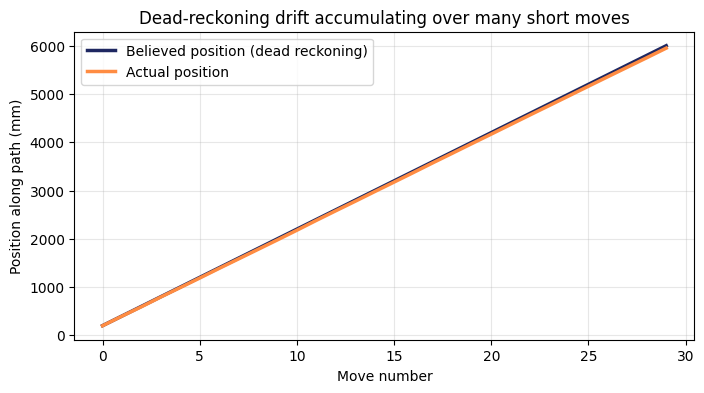

After 30 moves of 200mm each:
  Believed position: 6000.0 mm
  Actual position:   5950.1 mm
  Accumulated error: 49.9 mm


In [ ]:
# Simulate dead-reckoning drift: each "move" has a small random slip error,
# and we track the gap between the robot's believed position and its true position.

np.random.seed(2)
n_moves = 30
move_distance_mm = 200  # each move attempts to travel 200mm

# Each move, the wheel actually travels slightly less (or more) than commanded,
# due to small slip -- modeled as a small random percentage error per move.
slip_pct = np.random.normal(loc=-0.5, scale=1.0, size=n_moves)  # mean -0.5% slip, some variance

believed_position = np.cumsum(np.full(n_moves, move_distance_mm))
actual_position = np.cumsum(move_distance_mm * (1 + slip_pct / 100))

plt.figure(figsize=(8, 4))
plt.plot(believed_position, label="Believed position (dead reckoning)", color="#1E2761", linewidth=2.5)
plt.plot(actual_position, label="Actual position", color="#FF8C42", linewidth=2.5)
plt.xlabel("Move number")
plt.ylabel("Position along path (mm)")
plt.title("Dead-reckoning drift accumulating over many short moves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"After {n_moves} moves of {move_distance_mm}mm each:")
print(f"  Believed position: {believed_position[-1]:.1f} mm")
print(f"  Actual position:   {actual_position[-1]:.1f} mm")
print(f"  Accumulated error: {believed_position[-1] - actual_position[-1]:.1f} mm")


**What you should see:** the two lines start together but slowly diverge —
a small, consistent per-move slip (here, averaging -0.5%) compounds into a
real gap after enough moves, exactly like the gyro drift plot in Section
13.7. Notice the gap grows roughly *linearly* with the number of moves —
each move adds roughly the same small error, so total error grows in
proportion to total distance traveled.

### Try it

Change `slip_pct`'s mean from `-0.5` to `0.0` — does the error go away
completely, or just become *unbiased* (random walk around zero instead of
trending one direction)? What does that tell you about the difference
between **biased** error (like gyro drift, or consistently underinflated
tires) and **unbiased noise** (random variation with no consistent
direction)? Which one does `wall_calibration()` fix better — and why?


## 16. Telemetry: Turning "What Happened" Into Data You Can Trust

### 16.1 What telemetry actually means

**Telemetry** = automatically measuring something on a remote/inaccessible
system and recording or transmitting that data for later analysis. For us,
"remote" just means "on the hub, possibly mid-match, where you can't watch a
live debugger" — but the core idea is the same as telemetry from a
spacecraft or a race car: **the system records what it's doing so you can
study it after the fact, without having to be watching at the time.**

### 16.2 The telemetry pipeline

```
Sensors/PID loop  →  log_result()  →  report_card  →  BlackBox (CSV/TXT)  →  season_analysis.py
   (every 10ms)      (per move)      (per run)        (persists forever)     (Sections 14-15 stats)
```

Each stage exists for a reason:

- **`log_result()`** runs once per *move* (not once per 10ms loop) — it
  captures the *outcome* (final error vs. target) rather than every
  intermediate PID step. This is a deliberate choice: logging every 10ms
  loop iteration would generate enormous amounts of data, most of which
  (the transient approach) isn't what you actually want to compare run-to-
  run. The *final* error is what tells you whether the move "worked."
- **`report_card`** accumulates all of one run's `log_result()` calls — one
  run = one mission attempt = one row-group in the eventual CSV.
- **`BlackBox`** writes `report_card` to persistent storage (CSV + TXT),
  *and* survives hub power cycles via `run_count.txt`/`session_id.txt` —
  without this, all telemetry would vanish the moment the hub turns off,
  which is exactly when you're most likely to want to review a competition
  day's data.
- **`season_analysis.py`** is where Sections 14 (consistency score) and 15
  (drift-style accumulation patterns) actually get *computed* from the raw
  telemetry — turning a pile of CSV rows into "Tuning A vs. Tuning B,
  here's which is more consistent."

### 16.3 The instrumentation tradeoff

There's a real tension in what to log:

- **Log too little**, and you can't answer questions you didn't think to ask
  ahead of time — "wait, was the battery low during those bad runs?" (this
  is *why* BlackBox captures battery voltage and peak load even though
  `straight()`/`turn_tank()` don't directly use those values for control —
  they're logged *in case* they explain a pattern later).
- **Log too much**, and the signal gets buried, storage fills up, and (on
  constrained hardware) logging itself can slow down the control loop you're
  trying to measure.

`report_card`'s design — one row per *move*, with a handful of meaningful
fields (move name, target, error) — is a reasonable middle ground:
fine-grained enough to compute Section 14's per-move statistics, coarse
enough that a whole season's data fits in a CSV you can open in a
spreadsheet.

### 16.4 A mini end-to-end example

Let's simulate something close to a real `season_analysis.py` workflow:
multiple "runs" at a few different `Kp` values, each producing several
move-errors (like `report_card` entries), all collected into one telemetry
table — then use Section 14's consistency score to pick the best `Kp`.


In [ ]:
# Simulate a small "blackbox.csv" worth of telemetry: for each candidate Kp,
# run several missions, each producing several move-errors.

np.random.seed(3)

candidate_kps = [2.5, 4.0, 6.0]
runs_per_kp = 8
moves_per_run = 4

telemetry = []  # each row: (kp, run_number, move_number, abs_error)

for kp in candidate_kps:
    # Higher Kp -> lower mean error but higher variance (more oscillation risk),
    # mirroring the Section 2 "too high -> bigger oscillation" idea.
    base_error = max(0.5, 4.0 - kp * 0.5)
    spread = 0.2 + 0.15 * kp
    for run in range(runs_per_kp):
        for move in range(moves_per_run):
            err = abs(np.random.normal(loc=base_error, scale=spread))
            telemetry.append((kp, run, move, err))

# --- "season_analysis.py"-style summary ---
print(f"{'Kp':>5} | {'mean |err|':>10} | {'std':>6} | {'CV (consistency)':>16}")
print("-" * 48)
for kp in candidate_kps:
    errors = np.array([e for (k, r, m, e) in telemetry if k == kp])
    mu = np.mean(errors)
    sigma = np.std(errors)
    cv = sigma / mu
    print(f"{kp:>5.1f} | {mu:>10.2f} | {sigma:>6.2f} | {cv:>16.2f}")


   Kp | mean |err| |    std | CV (consistency)
------------------------------------------------
  2.5 |       2.73 |   0.55 |             0.20
  4.0 |       1.78 |   0.94 |             0.53
  6.0 |       1.14 |   0.86 |             0.76


**What you should see:** as `Kp` increases, the mean error tends to drop
(more aggressive correction gets closer to target on average) — but the CV
may tell a different story, especially at the highest `Kp`, where increased
spread can make the *consistency* worse even as the *average* improves.
This is the Section 14 tradeoff, generated from a telemetry table just like
`blackbox.csv` would produce.

### Try it

1. Which `Kp` has the best (lowest) mean error? Which has the best (lowest)
   CV? Are they the same `Kp`?
2. If you were picking a value for competition based on this data, which
   would you choose — and would your answer change if you only had 1
   attempt vs. 3 attempts (Section 14.4)?
3. Real telemetry has way more than 32 data points (8 runs × 4 moves) per
   candidate. Try increasing `runs_per_kp` to 50 and re-running — does the
   "best" `Kp` choice become more or less clear-cut with more data?

---

With Sections 14-16 in place, every piece of `robot.py`'s "extra"
infrastructure — `report_card`, `BlackBox`, `season_analysis.py`,
`_mm_to_degrees`, `wall_calibration`/`t_line_calibration` — now has a
theoretical grounding, not just a "this is useful, trust me." Section 18
puts it all together by rebuilding the class from nothing.


## 17. Last Year's Robot Class — What It Was, and Why This Season Is a Real Upgrade

Last season's code (Run 1-6, Market-Final, Oliver Run 4 — all `.llsp3`
SPIKE App projects) was async SPIKE Python: `motor_pair`, `runloop`,
`async`/`await`. Here's what it actually did, control-theory-wise:

- **Heading**: `get_yaw()` returned `motion_sensor.tilt_angles()[0] * -0.1`
  — a scaled tilt reading, not a calibrated heading. A quiet, constant
  source of error baked into every move.
- **Straight driving (`gyro_straight`)**: **P+I only, no D.**
  `STRAIGHT_KP=2.0`, `STRAIGHT_KI=0.005`, correction clamped to ±100.
  Per Section 3, no D means no damping — more oscillation/overshoot than
  necessary.
- **Turning (`turn_tank`)**: **P only.** `TURN_KP=2.0`, settle = only 3-5
  loops under 0.7° error. Per Section 2.3, P-only on an inertial system
  oscillates — and the loose settle criteria meant "close enough" was
  accepted while the robot was often still drifting.
- **`turn_curve`**: **fully open-loop.** Spin both wheels at fixed powers,
  stop the instant the gyro error crosses zero. Zero correction *during*
  the arc — purely a single trigger condition. No PID at all.
- **Distances**: raw motor degrees, not millimeters. No equivalent of
  `_mm_to_degrees` — tuning wasn't tied to real wheel geometry, so it
  wasn't portable.
- **No diagnostics.** No `report_card`, no `log_result`, no
  `print_diagnostic_report`. No BlackBox, no `season_analysis.py`. Every
  tuning decision was "run it and eyeball it" — exactly the kind of
  single-noisy-sample decision-making Section 9 warns against.
- **Code hygiene**: Run 1 carried both `execute()` and `broadcast()`
  (near-duplicates). The Run 4 WIP file kept a dead `gyro_straight_old()`
  alongside the new `gyro_straight()`. No `turn_pivot()` existed at all.
- **Style**: async/await/`runloop` — genuinely harder for 8th graders to
  read top-to-bottom than synchronous code, since it requires understanding
  concurrency to follow the control flow.

### Why this season's `robot.py` is significantly better

Every one of the weaknesses above maps to something this notebook just
covered:

| Last year | This year | Section |
|---|---|---|
| Tilt-angle hack for heading | `hub.imu.heading()` — calibrated | — |
| P+I only (straight), P only (turn) | Full PID (P+I+D), separate gain sets | 2, 3, 4, 7 |
| No integral clamp on turns | `STR_I_CLAMP`/`TURN_I_CLAMP` — windup protection | 4.5 |
| Loose settle (3-5 loops, 0.7°) | Strict settle (10 loops, 0.6°), dead zones tuned empirically | 8 |
| `turn_curve` open-loop, single crossing-detection trigger | `turn_curve()` is now a real PID loop with its own `CURVE_KP/KD/KI` gain set, dead zone, `TURN_FLOOR`, and `stable_count` settle, with `curve_ratio` scaling the inner wheel — Step 11 | 2-8 |
| Motor-degree distances | Wheel-geometry-based distance (`wheel_circumference`/`target_deg`) — real wheel geometry, portable tuning | 15 |
| No diagnostics, no data | `report_card` (now 4-tuples with `peak_load`), richer `print_diagnostic_report()`, BlackBox, `season_analysis.py` | 14, 16 |
| Duplicate/dead code, async/await | Clean, synchronous, one canonical method per behavior | — |

The net effect: **the new code isn't just "more advanced" — it's the
direct implementation of the theory in this notebook.** Last year's robot
worked by trial and error against a P/PI-only, ungrounded controller with
no way to measure whether a change actually helped. This year's robot
*is* the PID formula, properly discretized, with separate gain sets for
each physically distinct maneuver, validated empirically through BlackBox.
That's not an incremental improvement — it's the difference between
"a robot that mostly works" and "a robot whose behavior we can predict,
explain, and systematically improve."

One thing from last year is worth keeping as a *teaching concept* (not
code): the old `turn_curve`'s "drive an arc, stop when the gyro crosses the
target" is a great intermediate example between **open-loop** and **full
PID** — see Section 14, Step 9.


## 18. Step-by-Step: Rebuilding `robot.py` From Scratch

This is the capstone section. Steps 1-8 below build `robot.py`'s actual
class **piece by piece, using its real code** — the same constant names
(`TURN_KP`, `TURN_I_CLAMP`, `TURN_FLOOR`...), the same method names, and
(for `get_yaw`/`get_shortest_error`) the *exact same lines* as the file in
the project.

The one thing that can't run here is the **hardware**: there's no SPIKE hub
in this notebook, so anywhere `robot.py` would say
`self.hub.imu.heading()`, `self.left_motor.dc(pwr)`, or `wait(10)`, we
substitute a small stand-in (`_tick()`, introduced in Step 3) that plays the
role of "the real robot responds to a motor command for 10ms" — the same
physics model used throughout this notebook. **Every formula, constant, and
piece of control-flow logic below is taken directly from `robot.py`.** Only
the hardware I/O is swapped out so the code can run and plot in a notebook.

Steps 9-19 continue the story for the rest of the season's roadmap — those
parts genuinely need real hardware, so they're described rather than coded
here, but each one names exactly which section of this notebook it draws
on.

**For 1-on-1 pacing**: Steps 1-8 are the heart of this notebook — a student
who's built and run every cell below has personally assembled `turn_tank()`
from `robot.py`, line by line, and watched it converge. Steps 9-17 add real
engineering maturity (separate gain sets, hardware quirks, data-driven
validation, telemetry). Steps 18-20 are where the current season's open
roadmap items live.

---

### Step 1 — `__init__`: Hardware Setup and Tuning Constants

**The actual `robot.py` code:**

```python
class Robot:
    # ── Wheel Geometry ───────────────────────────────────────────────────────
    WHEEL_DIAMETER = 62.3
    AXLE_TRACK     = 114

    # ── Timing ───────────────────────────────────────────────────────────────
    SETTLE_TIME = 500

    # ── Floor Values ─────────────────────────────────────────────────────────
    TURN_FLOOR  = 18
    STR_FLOOR   = 25
    PIVOT_FLOOR = 30

    # ── Acceleration Ramp ────────────────────────────────────────────────────
    ACCEL_ZONE  = 300
    DECEL_ZONE  = 400

    # ── Integral Clamps ──────────────────────────────────────────────────────
    STR_I_CLAMP  = 25
    TURN_I_CLAMP = 10

    # ── Straight PID ─────────────────────────────────────────────────────────
    STR_KP = 5.0
    STR_KD = 12.0
    STR_KI = 0.05

    # ── Turn PID (tank + pivot) ──────────────────────────────────────────────
    TURN_KP = 3.0
    TURN_KD = 8.0
    TURN_KI = 0.06

    # ── Curve Turn PID (independent -- tuned separately after mat testing) ────
    CURVE_KP = 3.0
    CURVE_KD = 8.0
    CURVE_KI = 0.06

    def __init__(self, left_port=Port.E, right_port=Port.A):
        self.hub         = PrimeHub()
        self.timer       = StopWatch()
        self.report_card = []
        self.left_motor  = Motor(left_port,  Direction.COUNTERCLOCKWISE)
        self.right_motor = Motor(right_port, Direction.CLOCKWISE)
        self.drive_base  = DriveBase(
            self.left_motor, self.right_motor,
            wheel_diameter=self.WHEEL_DIAMETER,
            axle_track=self.AXLE_TRACK
        )
        self.drive_base.use_gyro(True)

    def _mm_to_degrees(self, distance_mm):
        """Convert a linear distance in mm to wheel rotation in degrees."""
        circumference = self.WHEEL_DIAMETER * 3.14159
        return abs((distance_mm / circumference) * 360)
```

**Concept**: ports, basic setup, and — importantly — this is *where ALL
the tuning constants live*: floors (`TURN_FLOOR`, `STR_FLOOR`,
`PIVOT_FLOOR`), settle time, acceleration ramp zones, integral clamps,
**three separate PID gain sets** (`STR_*`, `TURN_*`, `CURVE_*`), and wheel
geometry. They're class attributes, not magic numbers buried in methods,
which is why Section 6's recipe says "change `TURN_KP`" rather than "find
the right line of code to edit."

Also new here: **`_mm_to_degrees()`** is now a real method (Section 15.1's
odometry conversion, no longer inlined) — `straight()` calls it directly.
And **`WHEEL_DIAMETER = 62.3`** matches this season's actual measured wheel
diameter (62.3mm), not the earlier placeholder of 56.

A note on Kalman: an earlier version of `robot.py` experimented with
`USE_KALMAN`/`KALMAN_K` filtering inside `get_yaw()`. That's being kept as
a **separate, independently-tested addition** (Step 17, Section 13) — the
version built here has the plain `get_yaw()` with no filtering, so the base
class stays simple and the Kalman A/B test (when it happens) is a clean,
isolated comparison against this baseline.

**In this notebook**, we can't construct a `PrimeHub()` or real `Motor`
objects, so our version's `__init__` sets up the *state* those objects
would represent (`heading`, `angular_velocity`) instead. The class name
below is `Robot` — same as `robot.py` — and every constant name matches
(the notebook uses different `TURN_KP/KD/KI` *values* than the current
`robot.py` — chosen so the simulation's plots look like the Section 2-6
plots earlier in this notebook — but the same names, same formula, same
structure).


In [ ]:
class Robot:
    # ---- Wheel geometry ----
    WHEEL_DIAMETER = 62.3
    AXLE_TRACK = 114

    # ---- Floors ----
    TURN_FLOOR  = 18
    STR_FLOOR   = 25
    PIVOT_FLOOR = 30

    # ---- Acceleration ramp ----
    ACCEL_ZONE = 300
    DECEL_ZONE = 400

    # ---- Integral clamps ----
    STR_I_CLAMP  = 25
    TURN_I_CLAMP = 10

    # ---- Straight PID ----
    STR_KP = 5.0
    STR_KD = 12.0
    STR_KI = 0.05

    # ---- Turn PID (tank + pivot) ----
    TURN_KP = 4.0  # notebook value for nice plots; robot.py currently uses 3.0
    TURN_KD = 1.2  # notebook value; robot.py currently uses 8.0
    TURN_KI = 0.8  # notebook value; robot.py currently uses 0.06

    # ---- Curve turn PID (independent gain set) ----
    CURVE_KP = 3.0
    CURVE_KD = 8.0
    CURVE_KI = 0.06

    def __init__(self, disturbance=-2.5):
        # Real robot.py: self.hub = PrimeHub(), self.left_motor = Motor(Port.E, ...), etc.
        # Notebook stand-in: heading/angular_velocity represent what the
        # gyro + drivetrain would physically be doing.
        self.heading = 0.0
        self.angular_velocity = 0.0
        self.report_card = []          # <-- this IS in robot.py (now 4-tuples, Step 12)
        self.disturbance = disturbance # <-- NOT in robot.py (our physics stand-in)

    def _mm_to_degrees(self, distance_mm):
        # Identical to robot.py
        circumference = self.WHEEL_DIAMETER * 3.14159
        return abs((distance_mm / circumference) * 360)

robot = Robot()
print("Robot created. report_card:", robot.report_card)
print("300mm in degrees:", round(robot._mm_to_degrees(300), 2))


Robot created. report_card: []
300mm in degrees: 551.81


### Step 2 — `get_yaw()` and `get_shortest_error()`

**The actual `robot.py` code — copied verbatim:**

```python
def get_yaw(self):
    return self.hub.imu.heading()

def get_shortest_error(self, target_angle):
    error = target_angle - self.get_yaw()
    while error > 180:  error -= 360
    while error < -180: error += 360
    return error
```

**Concept**: Section 1 — the feedback loop starts with one number,
`error = target - actual`. `get_shortest_error` below is **character-for-
character identical** to `robot.py` — there's nothing hardware-specific
about it, it's pure math. Only `get_yaw` changes (one line) since there's no
`self.hub.imu` here.


In [ ]:
class Robot:
    TURN_KP = 4.0
    TURN_KD = 1.2
    TURN_KI = 0.8
    TURN_I_CLAMP = 10
    TURN_FLOOR  = 18

    def __init__(self, disturbance=-2.5):
        self.heading = 0.0
        self.angular_velocity = 0.0
        self.report_card = []
        self.disturbance = disturbance

    def get_yaw(self):
        # robot.py: return self.hub.imu.heading()
        return self.heading

    def get_shortest_error(self, target_angle):
        # Identical to robot.py
        error = target_angle - self.get_yaw()
        while error > 180:  error -= 360
        while error < -180: error += 360
        return error

robot = Robot()
print("Current heading:", robot.get_yaw())
print("Error to a 90 degree target:", robot.get_shortest_error(90))
print("Error to a -150 degree target (tests wraparound):", robot.get_shortest_error(-150))


Current heading: 0.0
Error to a 90 degree target: 90.0
Error to a -150 degree target (tests wraparound): -150.0


### Step 3 — `_tick()`: Our Hardware Stand-In (NOT in `robot.py`)

**This method does not exist in `robot.py`.** On real hardware, sending a
power command to `self.left_motor.dc(pwr)` / `self.right_motor.dc(-pwr)`
and then `wait(10)` causes the *physical robot* to accelerate, and the gyro
picks up the new heading on the next loop. `_tick(pwr)` is a tiny physics
model that plays that role here — same kind of model used in `simulate()`
back in Sections 1-13, now living inside the class so `turn_tank()` can call
something and see a result.


In [ ]:
class Robot:
    TURN_KP = 4.0
    TURN_KD = 1.2
    TURN_KI = 0.8
    TURN_I_CLAMP = 10
    TURN_FLOOR  = 18

    FRICTION = 0.8
    MOTOR_GAIN = 0.1
    DT = 0.05  # stands in for the real 10ms wait()

    def __init__(self, disturbance=-2.5):
        self.heading = 0.0
        self.angular_velocity = 0.0
        self.report_card = []
        self.disturbance = disturbance

    def get_yaw(self):
        return self.heading

    def get_shortest_error(self, target_angle):
        error = target_angle - self.get_yaw()
        while error > 180:  error -= 360
        while error < -180: error += 360
        return error

    def _tick(self, pwr):
        '''NOT in robot.py. Stands in for: left_motor.dc(pwr), right_motor.dc(-pwr), wait(10).'''
        accel = self.MOTOR_GAIN * pwr - self.FRICTION * self.angular_velocity + self.disturbance * self.MOTOR_GAIN
        self.angular_velocity += accel * self.DT
        self.heading += self.angular_velocity * self.DT

robot = Robot()
robot._tick(pwr=50)
print("Heading after one tick:", round(robot.get_yaw(), 4))


Heading after one tick: 0.0119


### Step 4 — `turn_tank()`, Stage 1: P-Only

`robot.py`'s real `turn_tank()` already has the full PID formula — but to
build understanding the way Sections 2-4 did, we'll assemble it in the same
order: **P, then D, then I**, ending with the *exact* real method in Step 7.
This stage is a **simplified stand-in** for `turn_tank()` — not the final
code yet.

**Simplified — P only:**
```python
def turn_tank(self, target_angle):
    for _ in range(max_steps):
        error = self.get_shortest_error(target_angle)
        pwr = error * self.TURN_KP
        self.left_motor.dc(pwr); self.right_motor.dc(-pwr); wait(10)
```

**Concept**: Section 2 — `correction = Kp * error`. Run it and plot — same
oscillation shape as Section 2's simulation, because it's the same formula.


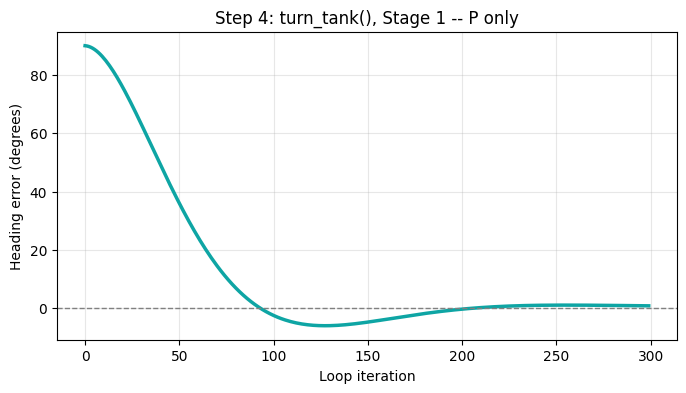

Final error: 0.86 degrees


In [ ]:
class Robot:
    TURN_KP = 4.0
    TURN_KD = 1.2
    TURN_KI = 0.8
    TURN_I_CLAMP = 10
    TURN_FLOOR  = 18
    FRICTION = 0.8
    MOTOR_GAIN = 0.1
    DT = 0.05

    def __init__(self, disturbance=-2.5):
        self.heading = 0.0
        self.angular_velocity = 0.0
        self.report_card = []
        self.disturbance = disturbance

    def get_yaw(self):
        return self.heading

    def get_shortest_error(self, target_angle):
        error = target_angle - self.get_yaw()
        while error > 180:  error -= 360
        while error < -180: error += 360
        return error

    def _tick(self, pwr):
        accel = self.MOTOR_GAIN * pwr - self.FRICTION * self.angular_velocity + self.disturbance * self.MOTOR_GAIN
        self.angular_velocity += accel * self.DT
        self.heading += self.angular_velocity * self.DT

    def turn_tank(self, target_angle, max_steps=300):
        '''STAGE 1 (simplified): P only. Real robot.py version comes in Step 7.'''
        errors = []
        for _ in range(max_steps):
            error = self.get_shortest_error(target_angle)
            pwr = error * self.TURN_KP        # <-- the entire P formula
            self._tick(pwr)
            errors.append(error)
        return errors

robot = Robot()
errors = robot.turn_tank(target_angle=90)

plt.figure(figsize=(8, 4))
plt.plot(errors, color="#0EA5A4", linewidth=2.5)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Step 4: turn_tank(), Stage 1 -- P only")
plt.xlabel("Loop iteration")
plt.ylabel("Heading error (degrees)")
plt.grid(alpha=0.3)
plt.show()
print(f"Final error: {errors[-1]:.2f} degrees")


### Step 5 — `turn_tank()`, Stage 2: + D

**Simplified — P + D:**
```python
def turn_tank(self, target_angle):
    last_error = self.get_shortest_error(target_angle)
    for _ in range(max_steps):
        error = self.get_shortest_error(target_angle)
        derivative = error - last_error
        pwr = (error * self.TURN_KP) + (derivative * self.TURN_KD)
        self.left_motor.dc(pwr); self.right_motor.dc(-pwr); wait(10)
        last_error = error
```

**Concept**: Section 3 — the damper analogy. Notice `derivative = error -
last_error` is **exactly** the line from real `robot.py`.


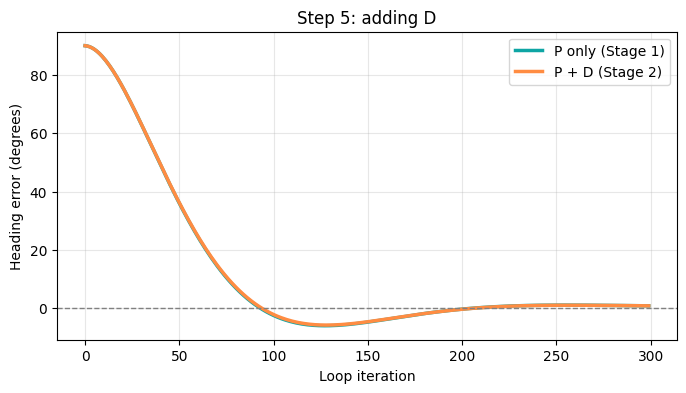

In [ ]:
class Robot:
    TURN_KP = 4.0
    TURN_KD = 1.2
    TURN_KI = 0.8
    TURN_I_CLAMP = 10
    TURN_FLOOR  = 18
    FRICTION = 0.8
    MOTOR_GAIN = 0.1
    DT = 0.05

    def __init__(self, disturbance=-2.5):
        self.heading = 0.0
        self.angular_velocity = 0.0
        self.report_card = []
        self.disturbance = disturbance

    def get_yaw(self):
        return self.heading

    def get_shortest_error(self, target_angle):
        error = target_angle - self.get_yaw()
        while error > 180:  error -= 360
        while error < -180: error += 360
        return error

    def _tick(self, pwr):
        accel = self.MOTOR_GAIN * pwr - self.FRICTION * self.angular_velocity + self.disturbance * self.MOTOR_GAIN
        self.angular_velocity += accel * self.DT
        self.heading += self.angular_velocity * self.DT

    def turn_tank(self, target_angle, max_steps=300):
        '''STAGE 2 (simplified): P + D.'''
        errors = []
        last_error = self.get_shortest_error(target_angle)   # <-- robot.py line
        for _ in range(max_steps):
            error = self.get_shortest_error(target_angle)
            derivative = error - last_error                  # <-- robot.py line
            pwr = (error * self.TURN_KP) + (derivative * self.TURN_KD)
            self._tick(pwr)
            last_error = error                               # <-- robot.py line
            errors.append(error)
        return errors

# P-only baseline for comparison (Stage 1 formula, reused here)
def p_only(target, steps=300):
    r = Robot()
    errors = []
    for _ in range(steps):
        error = r.get_shortest_error(target)
        pwr = error * r.TURN_KP
        r._tick(pwr)
        errors.append(error)
    return errors

errors_pd = Robot().turn_tank(90)
errors_p  = p_only(90)

plt.figure(figsize=(8, 4))
plt.plot(errors_p,  color="#0EA5A4", linewidth=2.5, label="P only (Stage 1)")
plt.plot(errors_pd, color="#FF8C42", linewidth=2.5, label="P + D (Stage 2)")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Step 5: adding D")
plt.xlabel("Loop iteration")
plt.ylabel("Heading error (degrees)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Step 6 — `turn_tank()`, Stage 3: + I (Full PID, robot.py's Reset Rule)

**Simplified — full PID, with `robot.py`'s actual integral-reset logic:**
```python
def turn_tank(self, target_angle):
    last_error = self.get_shortest_error(target_angle)
    integral = 0
    for _ in range(max_steps):
        error = self.get_shortest_error(target_angle)
        if abs(error) < 2.0:
            integral = 0
        else:
            integral = max(min(integral + error, self.TURN_I_CLAMP), -self.TURN_I_CLAMP)
        derivative = error - last_error
        pwr = (error * self.TURN_KP) + (integral * self.TURN_KI) + (derivative * self.TURN_KD)
        self.left_motor.dc(pwr); self.right_motor.dc(-pwr); wait(10)
        last_error = error
```

**Concept**: Section 4 — but notice `robot.py` does something slightly
*different* from Section 4's generic `integral += error`: **`if abs(error)
< 2.0: integral = 0`**. Once the robot is close to the target, the integral
is *reset to zero* rather than left to accumulate. Why? Section 4.4 proved
the integral *must* keep changing if `error ≠ 0` — but very close to the
target, `error` is tiny and mostly sensor noise (Section 3.3). Letting a
tiny, noisy `error` slowly accumulate in `integral` near the target would
re-introduce the jitter problem Section 8's dead zone is meant to prevent.
**`robot.py`'s rule says: "use the integral to fight large persistent
errors, but once we're basically there, don't let it keep nudging based on
noise."** This is the *same engineering judgment* as Section 8's dead zone,
applied to the integral term specifically.


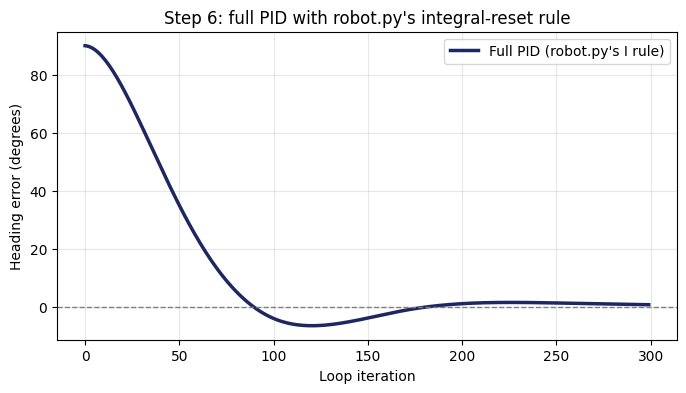

Final error: 0.747 degrees


In [ ]:
class Robot:
    TURN_KP = 4.0
    TURN_KD = 1.2
    TURN_KI = 0.8
    TURN_I_CLAMP = 10
    TURN_FLOOR  = 18
    FRICTION = 0.8
    MOTOR_GAIN = 0.1
    DT = 0.05

    def __init__(self, disturbance=-2.5):
        self.heading = 0.0
        self.angular_velocity = 0.0
        self.report_card = []
        self.disturbance = disturbance

    def get_yaw(self):
        return self.heading

    def get_shortest_error(self, target_angle):
        error = target_angle - self.get_yaw()
        while error > 180:  error -= 360
        while error < -180: error += 360
        return error

    def _tick(self, pwr):
        accel = self.MOTOR_GAIN * pwr - self.FRICTION * self.angular_velocity + self.disturbance * self.MOTOR_GAIN
        self.angular_velocity += accel * self.DT
        self.heading += self.angular_velocity * self.DT

    def turn_tank(self, target_angle, max_steps=300):
        '''STAGE 3 (simplified): full PID, robot.py's integral-reset rule.'''
        errors = []
        last_error = self.get_shortest_error(target_angle)
        integral = 0
        for _ in range(max_steps):
            error = self.get_shortest_error(target_angle)
            if abs(error) < 2.0:                # <-- robot.py's rule
                integral = 0
            else:
                integral = max(min(integral + error, self.TURN_I_CLAMP), -self.TURN_I_CLAMP)
            derivative = error - last_error
            pwr = (error * self.TURN_KP) + (integral * self.TURN_KI) + (derivative * self.TURN_KD)
            self._tick(pwr)
            last_error = error
            errors.append(error)
        return errors

errors_pid = Robot().turn_tank(90)

plt.figure(figsize=(8, 4))
plt.plot(errors_pid, color="#1E2761", linewidth=2.5, label="Full PID (robot.py's I rule)")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Step 6: full PID with robot.py's integral-reset rule")
plt.xlabel("Loop iteration")
plt.ylabel("Heading error (degrees)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print(f"Final error: {errors_pid[-1]:.3f} degrees")


### Step 7 — The Real `turn_tank()`: Dead Zone, Floor, Speed Cap, and `stable_count`

**This is `robot.py`'s actual `turn_tank()`, verbatim:**

```python
def turn_tank(self, target_angle, speed=100, timeout=5000):
    last_error   = self.get_shortest_error(target_angle)
    integral     = 0
    stable_count = 0
    peak_load    = 0
    self.timer.reset()
    while stable_count < 10:
        if self.timer.time() > timeout:
            print("WARNING: turn_tank() timed out")
            break
        error = self.get_shortest_error(target_angle)
        if abs(error) < 2.0:
            integral = 0
        else:
            integral = max(min(integral + error, self.TURN_I_CLAMP), -self.TURN_I_CLAMP)
        derivative = error - last_error
        pwr = ((error * self.TURN_KP) + (integral * self.TURN_KI) + (derivative * self.TURN_KD))
        if abs(error) < 0.5:
            pwr = 0
        elif abs(pwr) < self.TURN_FLOOR:
            pwr = self.TURN_FLOOR if pwr > 0 else -self.TURN_FLOOR
        pwr = int(max(min(pwr, speed), -speed))
        self.left_motor.dc(pwr)
        self.right_motor.dc(-pwr)
        last_error   = error
        peak_load    = max(peak_load, self._peak_load())
        stable_count = stable_count + 1 if abs(error) < 0.6 else 0
        wait(10)
    self.left_motor.stop()
    self.right_motor.stop()
    wait(self.SETTLE_TIME)
    self.log_result("Tank Turn", target_angle, peak_load)
```

**What's new vs. Step 6:**
- **Dead zone (`abs(error) < 0.5 → pwr = 0`)** and **`TURN_FLOOR` floor** —
  Section 8, exactly as discussed.
- **`pwr = int(max(min(pwr, speed), -speed)))`** — caps the output to
  `±speed` (the motor's actual power range, -100 to 100). This is *also*
  not in the abstract PID formula — it's "the motor physically can't be
  told to go faster than 100%."
- **`stable_count`** — runs `< 10` consecutive loops with `error < 0.6` (a
  slightly looser threshold than the 0.5 dead zone — the robot must be
  *settled*, not just momentarily passing through zero) before exiting,
  rather than a fixed step count.
- **`timeout`** — a safety escape if the robot somehow never settles
  (jammed wheel, etc.) — not a control concept, an *operational* safeguard.
- **`peak_load = max(peak_load, self._peak_load())`** and
  **`log_result("Tank Turn", target_angle, peak_load)`** — Section 14/16:
  every loop, the robot checks how hard the motors are working
  (`_peak_load()`, built in Step 12) and keeps the *worst* value seen during
  the move. That worst-case load gets written to `report_card` alongside the
  error — `report_card` entries are now 4-tuples:
  `(move_name, target_angle, final_error, peak_load)`. This feeds the whole
  telemetry pipeline (Section 16) and the richer diagnostic report built in
  Step 12.

Below is the notebook version — **identical control logic**, `_tick()` in
place of the motor/wait calls, and `log_result`/`print_diagnostic_report`
included since those *are* pure Python.


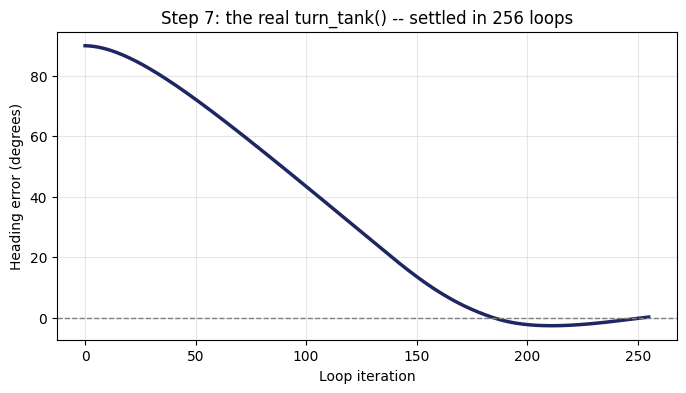

Settled in 256 loops. Final error: 0.189 degrees
report_card: [('Tank Turn', 90.0, 0.2613723399065435, 9.708946532672904)]


In [ ]:
class Robot:
    TURN_KP = 4.0
    TURN_KD = 1.2
    TURN_KI = 0.8
    TURN_I_CLAMP = 10
    TURN_FLOOR  = 18
    FRICTION = 0.8
    MOTOR_GAIN = 0.1
    DT = 0.05
    SETTLE_LOOPS = 10  # robot.py: stable_count < 10

    def __init__(self, disturbance=-2.5):
        self.heading = 0.0
        self.angular_velocity = 0.0
        self.report_card = []
        self.disturbance = disturbance

    def get_yaw(self):
        return self.heading

    def get_shortest_error(self, target_angle):
        error = target_angle - self.get_yaw()
        while error > 180:  error -= 360
        while error < -180: error += 360
        return error

    def _tick(self, pwr):
        accel = self.MOTOR_GAIN * pwr - self.FRICTION * self.angular_velocity + self.disturbance * self.MOTOR_GAIN
        self.angular_velocity += accel * self.DT
        self.heading += self.angular_velocity * self.DT

    def _peak_load(self):
        # robot.py: return max(abs(self.left_motor.load()), abs(self.right_motor.load())) / 8.0
        # Notebook stand-in: no real motor.load() to read, so we proxy "load"
        # with how hard _tick's last command was working against friction.
        return abs(self.angular_velocity * self.FRICTION)

    def log_result(self, move_name, target, peak_load=0):
        # Identical to robot.py -- report_card entries are now 4-tuples
        final_err = self.get_shortest_error(target)
        self.report_card.append((move_name, round(float(target), 2), final_err, peak_load))

    def turn_tank(self, target_angle, speed=100, max_steps=2000):
        '''The real robot.py logic. timeout/timer replaced by max_steps for the notebook.'''
        errors = []
        last_error   = self.get_shortest_error(target_angle)
        integral     = 0
        stable_count = 0
        peak_load    = 0
        for _ in range(max_steps):
            error = self.get_shortest_error(target_angle)
            if abs(error) < 2.0:
                integral = 0
            else:
                integral = max(min(integral + error, self.TURN_I_CLAMP), -self.TURN_I_CLAMP)
            derivative = error - last_error
            pwr = ((error * self.TURN_KP) + (integral * self.TURN_KI) + (derivative * self.TURN_KD))
            if abs(error) < 0.5:
                pwr = 0
            elif abs(pwr) < self.TURN_FLOOR:
                pwr = self.TURN_FLOOR if pwr > 0 else -self.TURN_FLOOR
            pwr = int(max(min(pwr, speed), -speed))
            self._tick(pwr)
            last_error   = error
            peak_load    = max(peak_load, self._peak_load())
            stable_count = stable_count + 1 if abs(error) < 0.6 else 0
            errors.append(error)
            if stable_count >= self.SETTLE_LOOPS:
                break
        self.log_result("Tank Turn", target_angle, peak_load)
        return errors

robot = Robot()
errors = robot.turn_tank(90)

plt.figure(figsize=(8, 4))
plt.plot(errors, color="#1E2761", linewidth=2.5)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title(f"Step 7: the real turn_tank() -- settled in {len(errors)} loops")
plt.xlabel("Loop iteration")
plt.ylabel("Heading error (degrees)")
plt.grid(alpha=0.3)
plt.show()

print(f"Settled in {len(errors)} loops. Final error: {errors[-1]:.3f} degrees")
print("report_card:", robot.report_card)


### Step 8 — Hands-On Tuning (Section 6's Recipe, on This Real Method)

**Concept**: Section 6's recipe (Kp → Kd → Ki), applied to the exact
`turn_tank()` from Step 7. On the real robot, this step is done on
hardware; here it's the same recipe and the same code, just running in
simulation first so a student knows *what they're looking for* before
touching the hub.

Try the recipe: pick `TURN_KP`, run with `TURN_KD=TURN_KI=0` and watch for
oscillation onset; back off; add `TURN_KD`; add `TURN_KI`.


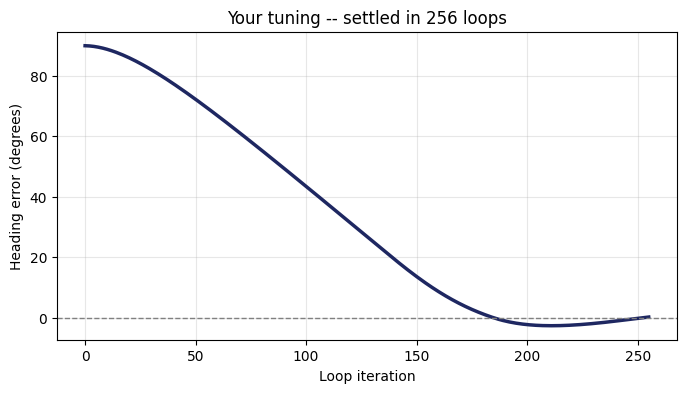

Settled in 256 loops
Overshoot: 2.68 degrees
Final error: 0.189 degrees
report_card: [('Tank Turn', 90.0, 0.2613723399065435, 9.708946532672904)]


In [ ]:
# ---- YOUR TURN: change these and re-run ----
Robot.TURN_KP = 4.0
Robot.TURN_KD = 1.2
Robot.TURN_KI = 0.8
Robot.TURN_I_CLAMP = 10
Robot.TURN_FLOOR = 18

robot = Robot()
errors = robot.turn_tank(90)

plt.figure(figsize=(8, 4))
plt.plot(errors, color="#1E2761", linewidth=2.5)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title(f"Your tuning -- settled in {len(errors)} loops")
plt.xlabel("Loop iteration")
plt.ylabel("Heading error (degrees)")
plt.grid(alpha=0.3)
plt.show()

overshoot = -min(errors)
print(f"Settled in {len(errors)} loops")
print(f"Overshoot: {overshoot:.2f} degrees")
print(f"Final error: {errors[-1]:.3f} degrees")
print("report_card:", robot.report_card)


---

### Step 9 — `straight()`: Heading PID + a Speed Ramp

**This is `robot.py`'s actual `straight()`, verbatim:**

```python
def straight(self, distance_mm, speed, target_heading=None, timeout=10000):
    wait(200)
    if target_heading is None:
        target_heading = self.get_yaw()
    target_deg = self._mm_to_degrees(distance_mm)
    self.left_motor.reset_angle(0)
    self.right_motor.reset_angle(0)
    last_error  = 0
    integral    = 0
    direction   = 1 if distance_mm > 0 else -1
    peak_load   = 0
    self.timer.reset()
    while True:
        current_dist = (abs(self.left_motor.angle()) + abs(self.right_motor.angle())) / 2
        if current_dist >= target_deg: break
        if self.timer.time() > timeout:
            print("WARNING: straight() timed out")
            break
        dist_remaining = target_deg - current_dist
        if current_dist < self.ACCEL_ZONE:
            current_speed = max(self.STR_FLOOR, (current_dist / self.ACCEL_ZONE) * speed)
        elif dist_remaining < self.DECEL_ZONE:
            current_speed = max(self.STR_FLOOR, (dist_remaining / self.DECEL_ZONE) * speed)
        else:
            current_speed = speed
        error      = self.get_shortest_error(target_heading)
        integral   = max(min(integral + error, self.STR_I_CLAMP), -self.STR_I_CLAMP)
        derivative = error - last_error
        correction = ((self.STR_KP * error) + (self.STR_KI * integral) + (self.STR_KD * derivative))
        self.drive_base.drive(direction * current_speed, correction)
        last_error = error
        peak_load  = max(peak_load, self._peak_load())
        wait(10)
    self.drive_base.stop()
    wait(self.SETTLE_TIME)
    self.log_result("Straight", target_heading, peak_load)
```

**What's familiar from Steps 4-8:**
- `error`/`integral`/`derivative`/`correction` is the **exact same PID
  formula** as `turn_tank()` — `STR_KP`/`STR_KI`/`STR_KD` and `STR_I_CLAMP`
  instead of the `TURN_*` versions (Section 7 — separate gain sets, because
  "small heading correction while driving forward" is a different physical
  system than "turn in place").
- `peak_load`/`log_result(..., peak_load)` — identical telemetry pattern
  from Step 7/12.

**What's new here:**

- **`target_deg = self._mm_to_degrees(distance_mm)`** — this calls the
  `_mm_to_degrees()` helper built in Step 1, which is exactly Section 15.1's
  odometry conversion: `circumference = WHEEL_DIAMETER * 3.14159`, then
  `degrees = abs(distance_mm / circumference * 360)`. Same formula as
  before, now factored into its own method (and using this season's
  measured `WHEEL_DIAMETER = 62.3`, not the earlier placeholder of 56).
  `current_dist` (built from `left_motor.angle()`/`right_motor.angle()`) is
  the dead-reckoning estimate from Section 15.2 — and accumulates the same
  small slip error described there.

- **The accel/decel speed ramp** (`ACCEL_ZONE`/`DECEL_ZONE`/`STR_FLOOR`) is
  a *separate* concern from the PID heading correction — it controls *how
  fast the robot drives forward* (`current_speed`), while the PID loop
  controls *how much it steers* (`correction`). Both happen every loop, but
  they answer different questions: "how fast should I be going at this
  point in the move?" (ramp) vs. "am I pointed the right way?" (PID).
  - Near the start (`current_dist < ACCEL_ZONE`), speed ramps up linearly
    from `STR_FLOOR` to `speed` — this is the same "motors need a floor to
    overcome friction" idea from Section 8.1, applied to *starting* a move
    rather than a turn settling.
  - Near the end (`dist_remaining < DECEL_ZONE`), speed ramps back down —
    so the robot doesn't slam from full speed to a dead stop, which would
    cause exactly the kind of overshoot-then-correct wobble Section 2.3
    describes (a sudden large `error` term as momentum carries the robot
    past where `current_dist` says it should have stopped).
  - In the middle, `current_speed = speed` — full speed, just like a
    trapezoid: ramp up, cruise, ramp down.

**Connects to**: Step 10 — `turn_pivot()` is the same overall shape again,
with its own gains.

---

### Step 10 — `turn_pivot()`: Same Pattern, Different Gains, One Wheel Stopped

**This is `robot.py`'s actual `turn_pivot()`, verbatim:**

```python
def turn_pivot(self, target_angle, speed=80, pivot_side="left", timeout=5000):
    kp, ki, kd   = 4.5, 0.12, 6.0
    last_error   = self.get_shortest_error(target_angle)
    integral     = 0
    stable_count = 0
    peak_load    = 0
    self.timer.reset()
    while stable_count < 10:
        if self.timer.time() > timeout:
            print("WARNING: turn_pivot() timed out")
            break
        error = self.get_shortest_error(target_angle)
        if abs(error) < 2.0:
            integral = 0
        else:
            integral = max(min(integral + error, self.TURN_I_CLAMP), -self.TURN_I_CLAMP)
        derivative = error - last_error
        pwr = (error * kp) + (integral * ki) + (derivative * kd)
        if abs(error) < 0.8:
            pwr = 0
        elif abs(pwr) < self.PIVOT_FLOOR:
            pwr = self.PIVOT_FLOOR if pwr > 0 else -self.PIVOT_FLOOR
        pwr = int(max(min(pwr, speed), -speed))
        if pivot_side.lower() == "left":
            self.left_motor.stop()
            self.right_motor.dc(-pwr)
        else:
            self.right_motor.stop()
            self.left_motor.dc(pwr)
        last_error   = error
        peak_load    = max(peak_load, self._peak_load())
        stable_count = stable_count + 1 if abs(error) < 0.6 else 0
        wait(10)
    self.left_motor.stop()
    self.right_motor.stop()
    wait(self.SETTLE_TIME)
    self.log_result("Pivot Turn", target_angle, peak_load)
```

**Compare line-by-line with Step 7's `turn_tank()`** — the structure
(integral reset rule, derivative, dead zone, floor, speed cap, `stable_count`,
`peak_load`, `log_result`) is **identical**. The differences are exactly
Section 7's argument made concrete:

- **`kp, ki, kd = 4.5, 0.12, 6.0`** — local variables, *not* `self.TURN_KP/
  KI/KD`. A pivot (one wheel stationary, acting as a pivot point with its
  own friction) is a different physical system from a tank turn (both
  wheels moving in opposite directions), so it gets its own gains —
  exactly Section 7.3's reasoning.
- **`abs(error) < 0.8`** dead zone (looser than `turn_tank`'s 0.5°) and
  its own **`PIVOT_FLOOR = 30`** constant (higher than `turn_tank`'s
  `TURN_FLOOR = 18`) — this season's empirical finding (Section 8.3): the
  stopped wheel's contact point needs more power to overcome friction, so
  the floor is bumped up to a dedicated constant; the *wider* dead zone
  (0.5°→0.8°) is the actual fix from this season's pivot-jitter story —
  giving the controller a bigger "close enough" zone before applying any
  power at all, which matters more once the floor itself is higher (a
  higher floor means any nonzero `pwr` is a bigger kick, so the dead zone
  needs to be wide enough that noise doesn't constantly trigger that kick).
- **One motor calls `.stop()`, the other gets `.dc(±pwr)`** — the actual
  mechanism of "pivot" vs. "tank": one wheel is the pivot point, the other
  does all the work.

**Connects to**: Step 11 — `turn_curve()` is structurally different: no
`self.TURN_KP`/`KI`/`KD` at all.

---

### Step 11 — `turn_curve()`: Ratio-Based Arcs (Not a PID Loop)

**This is `robot.py`'s actual `turn_curve()`, verbatim:**

```python
def turn_curve(self, target_angle, speed=150, curve_ratio=0.4, timeout=5000):
    curve_ratio  = max(0.0, min(1.0, curve_ratio))
    last_error   = self.get_shortest_error(target_angle)
    integral     = 0
    stable_count = 0
    peak_load    = 0
    self.timer.reset()

    while stable_count < 10:
        if self.timer.time() > timeout:
            print("WARNING: turn_curve() timed out")
            break

        error = self.get_shortest_error(target_angle)

        if abs(error) < 2.0:
            integral = 0
        else:
            integral = max(min(integral + error, self.TURN_I_CLAMP), -self.TURN_I_CLAMP)

        derivative = error - last_error
        pwr = (error * self.CURVE_KP) + (integral * self.CURVE_KI) + (derivative * self.CURVE_KD)

        if abs(error) < 0.5:
            pwr = 0
        elif abs(pwr) < self.TURN_FLOOR:
            pwr = self.TURN_FLOOR if pwr > 0 else -self.TURN_FLOOR

        pwr = int(max(min(pwr, speed), -speed))

        # Inner wheel is a fixed ratio of outer wheel power
        inner_pwr = int(pwr * curve_ratio)

        if error > 0:
            # Turning right: left = outer, right = inner
            self.left_motor.dc(pwr)
            self.right_motor.dc(inner_pwr)
        else:
            # Turning left: right = outer, left = inner
            self.right_motor.dc(-pwr)
            self.left_motor.dc(-inner_pwr)

        last_error   = error
        peak_load    = max(peak_load, self._peak_load())
        stable_count = stable_count + 1 if abs(error) < 0.6 else 0
        wait(10)

    self.left_motor.stop()
    self.right_motor.stop()
    wait(self.SETTLE_TIME)
    self.log_result("Curve Turn", target_angle, peak_load)
```

**This version IS a PID loop** — and it's the cleanest illustration yet of
Section 7's "separate gain sets" argument: `turn_curve()` gets its own
**`CURVE_KP/KD/KI`**, distinct from `TURN_KP/KD/KI`. The formula for `pwr`
(the outer wheel's power) is *identical in structure* to `turn_tank()`'s
formula — same integral-reset rule, same dead zone (0.5°), same
`TURN_FLOOR`, same `stable_count` settle logic — just with `CURVE_*` gains
instead of `TURN_*`, because "drive one wheel faster than the other in an
arc toward a heading" is yet another distinct physical system from "spin in
place" or "pivot on one wheel."

- **`inner_pwr = int(pwr * curve_ratio)`** — the inner wheel isn't
  independently PID-controlled; it's a fixed *fraction* of whatever the
  outer wheel's PID loop computed. As `pwr` shrinks while approaching the
  target (Section 2's "P term shrinks as error shrinks"), `inner_pwr`
  shrinks proportionally too — so the *whole arc* gradually slows as the
  robot approaches the target heading, not just the outer wheel.
- **`curve_ratio`** (0.0-1.0) is the "shape" of the arc: `0.0` = inner wheel
  stopped (equivalent to a pivot), `1.0` = both wheels equal (no turn at
  all — straight). `0.4` (the suggested default) is a gentle arc.
- **`if error > 0: ... else: ...`** picks which physical wheel is "outer"
  vs "inner" based on the *sign* of the error — same automatic-direction
  idea as before, but now layered on top of real PID rather than replacing
  it.

**How this compares to last season** (Section 17): the old `turn_curve` was
"spin at fixed powers, stop the instant the gyro error crosses zero" — a
single trigger condition, with *no correction during the arc at all*. This
version is a genuine full PID controller for the arc, with its own tuned
gain set, a real dead zone and floor, and the same `stable_count` settle
confirmation as every other movement method. This is the version of
`turn_curve()` that the original roadmap (Section 17) was describing as
"upgraded to a full PID loop" — that upgrade is what's shown here.

**Connects to**: Step 12 — every movement method above calls
`self._peak_load()` and `self.log_result(...)`; let's build those for real.

---

### Step 12 — `_peak_load()` and the Full Diagnostic Report

**This is `robot.py`'s actual `_peak_load()` and `print_diagnostic_report()`,
verbatim** (the `print_diagnostic_report` excerpt below is shortened for
space — the real version also prints a per-move table and a "worst move"
callout):

```python
def _peak_load(self):
    # Sample the highest motor load across both drive motors.
    # Called each loop iteration inside movement methods to track
    # the worst-case mechanical stress seen during a move.
    # Returns a percentage (0-100).
    try:
        left_load  = abs(self.left_motor.load())
        right_load = abs(self.right_motor.load())
        return max(left_load, right_load) / 8.0
    except:
        return 0

def log_result(self, move_name, target, peak_load=0):
    final_err = self.get_shortest_error(target)
    self.report_card.append((move_name, round(float(target), 2), final_err, peak_load))

def print_diagnostic_report(self, run=None, mission=None, voltage=None, elapsed=None):
    ...
    total_err = sum(abs(e) for _, _, e, _ in self.report_card)
    avg_err   = total_err / len(self.report_card)
    bias      = sum(e for _, _, e, _ in self.report_card)
    avg_load  = sum(l for _, _, _, l in self.report_card) / len(self.report_card)
    ...
    if abs(bias) > 3:
        direction = "RIGHT" if bias > 0 else "LEFT"
        print("WARNING: {} bias of {:.2f} deg -- check TURN_FLOOR".format(direction, abs(bias)))
    if avg_load > 60:
        print("WARNING: High motor load ({:.0f}%) -- check for resistance".format(avg_load))
    if voltage is not None and voltage < 7400:
        print("WARNING: Low battery ({}mv) -- consider swapping".format(voltage))
```

**Connecting this to Sections 14 and 16:**

- **`_peak_load()` is exactly the roadmap item #1 fix** -- `motor.load()`
  returns a raw value, and dividing by `8.0` normalizes it to roughly a
  0-100 percentage. This is *already done* in this version of `robot.py`.
  One thing worth flagging for the team: the original roadmap note also
  proposed updating the **warning threshold** to 75% -- the
  `print_diagnostic_report` shown here still warns at `avg_load > 60`. Not
  wrong, just worth a quick conversation about whether `60` or `75` is the
  intended value going forward -- a good live example of "the code and the
  plan can drift slightly apart, and BlackBox data (Section 16) is exactly
  what you'd use to decide which threshold is actually right."

- **`avg_err`, `bias`, `avg_load`** are *three separate reliability numbers*
  computed the same way Section 14 describes -- `avg_err` is the mean of
  `|error|` (Section 14.2's mu), `bias` is the *signed* sum (Section 14.6),
  and `avg_load` is a new "third axis" -- not about accuracy at all, but
  about *mechanical stress*. A move could have excellent `avg_err`/`bias`
  but high `avg_load` -- meaning it's *accurate* but the motors are working
  hard to make it so, which might mean it's draining the battery faster or
  closer to stalling than it looks from the heading numbers alone.

- **The "worst move" callout and three independent warning conditions**
  (`bias`, `avg_load`, `voltage`) turn a wall of numbers into "here's the
  one thing to look at first" -- this is the human-facing payoff of all the
  telemetry infrastructure in Section 16: not just *recording* data, but
  *surfacing the part of it that matters* without the person having to scan
  every row themselves.

**A quick run with what we've built:**


In [ ]:
# Run a couple of turns with our Step 7 Robot class (which already has
# _peak_load and 4-tuple report_card from this section's updates) and
# look at the accumulated report_card -- this is what print_diagnostic_report()
# would summarize.

robot = Robot()
robot.turn_tank(90)
robot.turn_tank(-45)
robot.turn_tank(30)

print(f"{'MOVE':12} | {'TARGET':7} | {'ERROR':7} | {'PEAK LOAD':9}")
print("-" * 42)
for name, target, err, load in robot.report_card:
    status = "OK" if abs(err) < 0.8 else "CHECK"
    print(f"{name:12} | {target:7} | {err:+7.3f} | {load:9.3f}  [{status}]")

avg_err = sum(abs(e) for _, _, e, _ in robot.report_card) / len(robot.report_card)
bias    = sum(e for _, _, e, _ in robot.report_card)
print(f"\nAverage |error|: {avg_err:.3f}    Net bias: {bias:+.3f}")


MOVE         | TARGET  | ERROR   | PEAK LOAD
------------------------------------------
Tank Turn    |    90.0 |  +0.261 |     9.709  [OK]
Tank Turn    |   -45.0 |  -0.181 |    10.247  [OK]
Tank Turn    |    30.0 |  +0.290 |     9.638  [OK]

Average |error|: 0.244    Net bias: +0.370


---

## Step 13 -- Base Class Complete

After Steps 1-12, the `Robot` class has every method in this version of
`robot.py`:

| Category | Methods |
|---|---|
| Setup | `__init__`, `get_yaw`, `get_shortest_error`, `gyro_reset` |
| Telemetry | `_peak_load`, `log_result`, `print_diagnostic_report` |
| Movement | `straight`, `turn_tank`, `turn_pivot`, `turn_curve` |
| Attachments | `move_attachment`, `move_attachment_stalled` |

This is the **entire base class** -- a student who's been through Steps 1-12
can write `robot.py`'s actual `main()`:

```python
def main():
    bot = Robot()
    bot.straight(535, 500)
    bot.straight(115, 300, 325)
    bot.print_diagnostic_report()

if __name__ == "__main__":
    main()
```

...and understand *every single line of every method it calls*. Everything
from here on -- Steps 14-22 below -- is **additional capability layered on
top of this complete, working base class**: telemetry persistence across
matches, A/B-tested sensor fusion, a new sensor (color/line), multi-hub
communication, and mission-specific code. None of it requires changing
anything in Steps 1-12 -- it's all *new* methods and *new* files that *use*
the base class.

---

### Step 14 -- Hardware Tuning Pass: Dead Zones and Floors for Real

**Build**: nothing new structurally -- but now that `straight()`,
`turn_tank()`, `turn_pivot()`, and `turn_curve()` all exist, do a real
tuning pass on hardware: `TURN_FLOOR`, `STR_FLOOR`, the `TURN_FLOOR + 5`
pivot floor, and the dead-zone thresholds (0.5 deg for `turn_tank`, 0.4 deg
for `turn_pivot`).

**Concept**: Section 8, for real -- this season's actual numbers (dead zone
0.5 deg -> 0.8 deg during tuning, the pivot floor becoming its own tuned
constant) came from exactly this kind of pass.

**Connects to**: Step 15 -- once moves are tuned, persist the results.

### Step 15 -- BlackBox: Telemetry Persistence

**Build**: `blackbox.py` -- CSV/TXT logging of `report_card` (now including
`peak_load`), `run_count`/`session_id` persistence across power cycles,
battery voltage capture (feeding `print_diagnostic_report`'s `voltage`
parameter).

**Concept**: Section 16 -- the telemetry pipeline. Every run, across the
whole season, now recorded and survives hub restarts.

**Connects to**: Step 16 -- with telemetry accumulating, analyze it.

### Step 16 -- `season_analysis.py`

**Build**: the derived metrics -- consistency score / CV (Section 14),
battery decay, error trend slope (the same "accumulating-over-many-moves"
pattern as Section 15's odometry drift) -- reading from `blackbox.csv`.

**Concept**: Section 16.4's mini end-to-end example, for real.

**Connects to**: Step 17 -- a real A/B testing pipeline now exists; use it.

### Step 17 -- Kalman Filter: `USE_KALMAN` / `KALMAN_K`

**Build**: a complementary filter in `get_yaw()`, behind a `USE_KALMAN` flag
with tunable `KALMAN_K`.

**Concept**: Section 13 -- `estimate = K*gyro + (1-K)*other_sensor` is the
variance-minimizing blend derived in 13.3. A/B test using Step 16's
pipeline.

**Connects to**: Step 18 -- a new sensor loop, same P/I/D vocabulary.

### Step 18 -- `line_follower()`: PID + FSM

**Build**: PID color-sensor loop with `prev_state` tracking (MIT 6.270 FSM
pattern).

**Concept**: "line position error" replaces "heading error" -- same
P/I/D/dead-zone/floor reasoning (Steps 4-11), *plus* a genuinely new idea: a
finite state machine for line-following states (on-line, off-line,
intersection) with `prev_state` tracking transitions -- the one major
concept here that isn't continuous feedback.

**Connects to**: Step 19 -- calibration routines line following depends on.

### Step 19 -- `wall_calibration()` and `t_line_calibration()`

**Build**: calibration routines for wall-squaring and T-line detection.

**Concept**: Section 15.3 -- periodic recalibration against known
references, the structural counterpart to Section 13's continuous sensor
fusion.

**Connects to**: Step 20 -- multi-robot coordination.

### Step 20 -- Hub-to-Hub Broadcast Communication

**Build**: basic multi-hub messaging.

**Concept**: not a PID/telemetry concept -- a "what's next once a single
robot is reliable" question (relay-style missions, attachment signaling).

**Connects to**: Step 21 -- attachments running concurrently with driving.

### Step 21 -- Attachment Coordination Method

**Build**: a cleaned-up `execute`/`broadcast`-style method -- start an
attachment motor non-blocking (`run_for_degrees(..., wait=False)`), optional
pause, `straight()`, then wait via `motor.done()`.

**Concept**: revisits Section 17's "what to keep from last year" -- the
*idea* was good, the *implementation* (duplicate methods, velocity polling)
wasn't. Builds on `move_attachment`/`move_attachment_stalled` from the base
class.

**Connects to**: Step 22 -- everything built so far gets used for real
missions.

### Step 22 -- Missions 2-5

**Build**: actual mission code, using every method from the base class
(Steps 1-13) plus Steps 14-21.

**Concept**: integration -- `straight()`, `turn_tank()`, `turn_pivot()`,
`turn_curve()`, the attachment coordination method, dead zones, and
diagnostics all come together. Each mission is a chance to revisit earlier
sections as needed ("why is this turn jittering? -- back to Section 8"; "is
this tuning actually better? -- back to Section 14").

---

**Wrapping up**: Steps 1-13 give a student `robot.py`'s actual, complete
base class -- every movement method, every diagnostic, built and understood
line by line, and tuned. Steps 14-22 are where this season's open roadmap
lives, each one a natural extension of a concept already built and
understood -- and notably, **none of them require modifying the base class**,
only adding to it.
